> **2026-09-18**: this notebook extends `Autophagy_Apoptosis_CoLoMoTo_Analysis_update.ipynb` (new phenotype markers, new analyses in Sections 10-15, and a fix to how internal-node initial states are set in the scenario comparisons). The original file is left untouched. Search for `[2026-09-18` inline for exactly what changed and why.


# Autophagy–Apoptosis Boolean Model — CoLoMoTo notebook

This notebook can be run with CoLoMoTo Docker or by creating a conda environment with the libraries of the CoLoMoTo suite

**Workflow**
1. Setup and environment configuration
2. Load and visualize the GINsim regulatory network
3. Compute stable states with bioLQM
4. Configure and run a MaBoSS simulation
5. Analyze fixpoints and check for limit cycles 
6. Simulate four stress scenarios and visualize Proliferation / Apoptosis / Beclin1 (`BECN1`) + 3 death signals
7. Simulate `BECN1` ON/OFF mutations
8. Simulate 'MTOR' treatment (rapamycin in four contexts)
9. Compare mutation results across scenarios, and conclude


## 1. Setup and Environment Configuration

Import the CoLoMoTo toolkit packages used in this notebook: `biolqm` (format conversion, stable states), `ginsim` (regulatory graph visualization), `maboss` (pyMaBoSS, stochastic simulation) and `mpbn` (attractor cross-check). These are provided by the `colomoto` conda environment.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

import biolqm
import maboss
import mpbn
import ginsim

import pandas as pd

import numpy as np
import seaborn as sns

#import bns
#import boolsim
from colomoto_jupyter import tabulate # For fixpoint table display.
import matplotlib.pyplot as plt # For modifying plots.



## 2. Load and Visualize the GINsim Network

Load the (updated) GINsim `.zginml` model and render the regulatory graph. The network has 126 components; we highlight `BECN1` (Beclin1, the death/survival switch), `Apoptosis` and `Proliferation`.

In [2]:
model_ginsim = ginsim.load("Autophagy_and_apoptosis_Sept26_2026-10-01.zginml")
ginsim.show(model_ginsim)

PHENOTYPES:

The proliferation node: activated when the cell cycle is ON

The senescence node: it activates when p21 is activated for a long time. 

The apoptosis node: is ulitmately activate by the executioner caspases. 

The autophagy nodes:
* Atphgo_form (autophagosome formation): The earliest step — LC3 lipidation + WIPI1 recruitment. Turns on as soon as core conjugation machinery is active.
* Atphgo_mat (autophagosome maturation): A later, stricter step — requires RAB7A on top of formation. This is the node that "gates" several apoptosis nodes (MOMP, BBC3, BCL2L11) — only mature autophagy is protective.
* Autop_digestion: Meant to represent actual cargo degradation, but currently just mirrors Atphgo_mat exactly (a known simplification — the real fusion/degradation machinery isn't modeled as a separate step).
* SQSTM1 (p62): Not autophagy itself — a flux marker. Accumulates specifically when digestion hasn't happened (blocked/insufficient autophagy), clears when it has.
* Autophagy: The composite "headline" output — ON if either formation or maturation is active. This is what drives the orange coloring and the nutrient-secretion trigger.
* Autophagy_sustained: A "shadow" delay node (same pattern as CHOP_sustained, p21_sustained) distinguishing a durable, repeated autophagy signal from a one-tick flicker.

SUSTAINED NODES:
* CHOP_sustained: required alongside CHOP itself in BCL2L11 (BIM) and in mRNA_BBC3 (PUMA transcription) because ER-stress-driven apoptotic commitment needs CHOP to look durable, not just momentarily true.
* p21_sustained: required in Senescence, cell-cycle arrest only becomes senescence commitment if p21 is durable.
* SP1_sustained: required in BBC3 specifically when autophagy is already mature (Atphgo_mat). An extra durability check on the SP1-driven route to PUMA.
* Autophagy_sustained: required (paired with SQSTM1) in H2O2's logic, representing genuinely prolonged/repeated autophagic activity, not a brief pulse.

TO VERIFY: does it really change the phenotypes if these nodes are removed? 

## 3. Compute Stable States with bioLQM

Load the model into bioLQM and enumerate its stable states (fixpoints of the fully asynchronous/Boolean dynamics). This gives the discrete, model-wide steady states independently of any particular input scenario or of MaBoSS's stochastic engine — a useful ground truth to compare the MaBoSS fixpoints against later on.

In [3]:
# Compute the stable states with biolqm
model_biolqm = ginsim.to_biolqm(model_ginsim) # convert to biolqm

fixpoints = biolqm.fixpoints(model_biolqm)
print(f"Number of stable states found by bioLQM: {len(fixpoints)}")

markers = ["BECN1", "Autop_digestion", "Apoptosis", "Proliferation", "Cell_cycle", "MTOR", "NFkappaB", "Autophagy", "Senescence"]
# add more if needed
fp_table = pd.DataFrame([{m: fp.get(m) for m in markers} for fp in fixpoints])
fp_table.index.name = "stable state #"
fp_table


Number of stable states found by bioLQM: 4


,BECN1,Autop_digestion,Apoptosis,Proliferation,Cell_cycle,MTOR,NFkappaB,Autophagy,Senescence
stable state #,,,,,,,,,
0,0,0,0,1,1,1,1,0,0
1,0,0,0,1,1,1,1,0,0
2,0,0,0,1,1,1,1,0,0
3,0,0,0,1,1,1,1,0,0


In [4]:
# Or show all genes

print(len(fixpoints), "stable states") # shows the number of fixpoints
pd_fps = pd.DataFrame(fixpoints) # Store the stable states in a panda dataframe
pd_fps

4 stable states


,Apoptosis,Proliferation,O_stress,Growth_factor,TNF_R_or_DR,AA_Starvation,NFE2L2,KEAP1,GSK3A,NQO1,STK11,ATM,Ulk_C,p21,TP53_nuc,FOXO,MTOR,ATG13,RB1CC1,TP53_cyto,ULK1,PRKA,EIF2AK3,RPTOR,TSC2,AMBRA1,MDM2,BCL2_BECN1_C,BECN1,AKT1,PIK3CA,RRAGA,ATG14,PIK3C3,RAB7A,UVRAG,PI3P,MAP1LC3A_II,ATG3,RPS6KB1,IRS1,PTEN,Atphgo_form,Atphgo_mat,RHEB,FKBP8,PPP2R,PDGFRA,EIF4E,RHOA,ROCK,NEDD4,EIF4EBP1,TRAF6,TFEB,MYC,MON1A,Atg16L_Atg5_Atg12,NFkappaB,IKBKB,NFKBIA,Autop_digestion,pRB,Cell_cycle,BAX,BBC3,MOMP,Cyt_C,Caspase9_APAF1_C,Caspase_3_6_7_C,BCL2L11,MAPK8,YWHAB,PINK1,PARK2,CASP8,DAPK1,MAP3K,PRKD1,MAP2K1,Lysosome_prod,BCL2,H2O2,MTOR_C2,BID,FLIP,RAS,RAF,SOS,GRB2,GAB,EGFR,Insuline,JIP,Kinesin_1,Tubulin,WIPI_1,SP1,mRNA_BBC3,ER_stress,Glucose_starv,Ca_cyto,CAMKKB,IRE1,IP3R,IP3R_VDAC,Mito_overcharge,mRNA_CHOP,CHOP,mRNA_BCL2,mRNA_BCL2L11,CHOP_sustained,ROMO1,mRNA_ROMO1,mRNA_ATF4,ATF4,mRNA_SP1,SP1_sustained,DNA_damage,CDKN2A,p21_sustained,Senescence,Autophagy,SQSTM1,Autophagy_sustained
0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,1,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


Conclusion: All stable states show a proliferative phenotype and no apoptosis. This is not expected and thus suggests the existence of limit cycles. We go further and test the model with most-permissive strategy.

## 3bis Compute attractors with MPBN

In [5]:
# 1. Convert the bioLQM model to minibn (used by mpbn)
bn = biolqm.to_minibn(model_biolqm)
mbn = mpbn.MPBooleanNetwork(bn)
# 2. Compute all attractors
attractors = list(mbn.attractors())
print(f"Total attractors found by mpbn: {len(attractors)}")
# 3. View the phenotype markers for each attractor
markers = ["Apoptosis", "Proliferation", "Autop_digestion", "BECN1", "Cell_cycle", "MTOR", "NFkappaB", "Autophagy", "Senescence"]
df_attractors = pd.DataFrame([{m: a.get(m) for m in markers} for a in attractors])
# Display the first few attractors
display(df_attractors.head(10))
# Display the summary of phenotypes (including limit cycles / oscillations '*')
display(df_attractors[["Apoptosis", "Proliferation", "Autop_digestion", "BECN1", "Autophagy", "Senescence"]].value_counts())

Total attractors found by mpbn: 128


,Apoptosis,Proliferation,Autop_digestion,BECN1,Cell_cycle,MTOR,NFkappaB,Autophagy,Senescence
0,0,1,0,0,1,1,1,0,0
1,0,1,0,0,1,1,1,0,0
2,0,1,0,0,1,1,1,0,0
3,0,1,0,0,1,1,1,0,0
4,1,0,0,0,0,0,1,0,1
5,1,0,0,0,0,0,1,0,1
6,1,0,0,0,0,0,1,0,1
7,1,0,0,0,0,0,1,0,1
8,1,0,0,0,0,0,1,0,1
9,1,0,0,0,0,0,1,0,1


Apoptosis  Proliferation  Autop_digestion  BECN1  Autophagy  Senescence
1          0              0                0      0          1             88
                                                             0             16
           *              0                0      0          *              8
*          0              *                *      *          1              8
0          1              0                0      0          0              4
*          *              *                *      *          0              4
Name: count, dtype: int64

In [6]:
## Used LLM to suggest a way to visualize the solutions

# Compute all attractors
attractors = list(mbn.attractors())
print(f"Total attractors found by mpbn: {len(attractors)}")
# Categorize each attractor (Fixed Point vs Cyclic / Limit Cycle)
records = []
for a in attractors:
    free_nodes = [k for k, v in a.items() if v == "*"]
    is_fixed_point = (len(free_nodes) == 0)
    
    apop = a.get("Apoptosis")
    prolif = a.get("Proliferation")
    autop = a.get("Autop_digestion")
    becn1 = a.get("BECN1")
    
    # Classify macro-phenotype
    if apop == 0 and prolif == 1:
        pheno = "Proliferative Survival"
    elif apop == 1 and prolif == 0:
        pheno = "Apoptotic Commitment"
    elif apop == 1 and prolif == "*":
        pheno = "Apoptotic / Fluctuating"
    else:
        pheno = "Dynamic Switch / Oscillatory"
        
    records.append({
        "Phenotype Class": pheno,
        "Type": "Fixed Point" if is_fixed_point else "Cyclic (Limit Cycle)",
        "Apoptosis": apop,
        "Proliferation": prolif,
        "Autop_digestion": autop,
        "BECN1": becn1,
    })

# Group into summary table with counts
df = pd.DataFrame(records)
summary_table = (
    df.groupby(["Phenotype Class", "Type", "Apoptosis", "Proliferation", "Autop_digestion", "BECN1"])
    .size()
    .reset_index(name="Count")
)

# Add biological interpretation and reorder columns
descriptions = {
    "Proliferative Survival": "Steady-state cell cycle progression (matches bioLQM fixpoints)",
    "Apoptotic Commitment": "Irreversible apoptotic death with proliferative shutdown",
    "Apoptotic / Fluctuating": "Apoptosis active, with upstream cell cycle oscillations (*)",
    "Dynamic Switch / Oscillatory": "Dynamic limit cycles under oxidative stress (autophagy & apoptosis oscillate)"
}
summary_table["Biological Meaning"] = summary_table["Phenotype Class"].map(descriptions)
cols = ["Phenotype Class", "Count", "Type", "Apoptosis", "Proliferation", "Autop_digestion", "BECN1", "Biological Meaning"]
summary_table = summary_table[cols].sort_values(by="Count", ascending=False)

# Display table
display(summary_table)

Total attractors found by mpbn: 128


,Phenotype Class,Count,Type,Apoptosis,Proliferation,Autop_digestion,BECN1,Biological Meaning
1,Apoptotic Commitment,104,Cyclic (Limit Cycle),1,0,0,0,Irreversible apoptotic death with proliferativ...
0,Apoptotic / Fluctuating,8,Cyclic (Limit Cycle),1,*,0,0,"Apoptosis active, with upstream cell cycle osc..."
2,Dynamic Switch / Oscillatory,8,Cyclic (Limit Cycle),*,0,*,*,Dynamic limit cycles under oxidative stress (a...
3,Dynamic Switch / Oscillatory,4,Cyclic (Limit Cycle),*,*,*,*,Dynamic limit cycles under oxidative stress (a...
4,Proliferative Survival,4,Fixed Point,0,1,0,0,Steady-state cell cycle progression (matches b...


It confirms the existence of complex cyclic attractors. For a more global understanding of the solutions, we study the dynamics with stochastic simulations with MaBoSS.

## 4. MaBoSS simulations

In [7]:
## MaBoSS simulations


BASE_INPUTS = {"AA_Starvation": 0, "Growth_factor": 0, "TNF_R_or_DR": 0, "O_stress": 0,
               "Glucose_starv": 0, "Insuline": 0, "DNA_damage": 0, "KEAP1": 1, "NQO1": 1}

OUTPUT_NODES = ["Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence", "SQSTM1"]

model_maboss = biolqm.to_maboss(model_biolqm) # convert to maboss
model_maboss.update_parameters(sample_count=5000,max_time=100, time_tick=0.1)

# Define custom output phenotype colour mapping
phenotypes_colors = {
    'Apoptosis': 'green',
    'Proliferation': 'red',
    'BECN1': 'blue',
    'Autop_digestion': 'black',
    'Autophagy': 'purple',
#    'Senescence': 'purple',
    'SQSTM1': 'orange'
}
# Define the color palette based on these colours
model_maboss.palette = phenotypes_colors


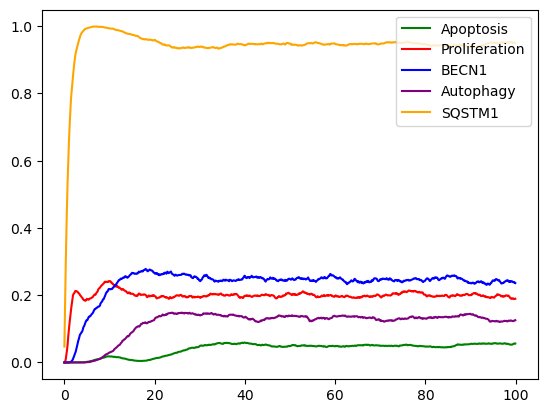

In [8]:
model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "SQSTM1", "Autophagy"))
run_model_maboss = model_maboss.run()
run_model_maboss.plot_node_trajectory()

In [9]:
fp_table = run_model_maboss.get_fptable()
print(fp_table)


None


In [10]:
# For all nodes of the network, set the initial state to random
for n in model_maboss.network:
    model_maboss.network.set_istate(n,[0.5,0.5])

InputsOFF = ["O_stress", "Growth_factor", "Glucose_starv", "AA_Starvation", "TNF_R_or_DR", "Insuline", "DNA_damage"]
for node in InputsOFF:
    model_maboss.network.set_istate(node, [1, 0])

InputsON = ["KEAP1", "NQO1"]
for node in InputsON:
    model_maboss.network.set_istate(node, [0, 1])
    
    
WT_allinputs = model_maboss.copy()

WT_allinputs.network.set_output(("Apoptosis", "Proliferation", "BECN1", "SQSTM1", "Autophagy"))
#WT_allinputs.network.set_output(("O_stress", "Growth_factor", "Glucose_starv", "AA_Starvation", "TNF_R_or_DR", "Insuline")
run_WT_allinputs = WT_allinputs.run()

WT_allinputs.palette = phenotypes_colors

Read-outs of the model:
* Apoptosis, Proliferation, Autophagy, Senescence: the four terminal fates.
* BECN1: the central autophagy-initiation switch this whole project's story revolves around.
* SQSTM1 (p62): tells you whether autophagy is completing (flux OK, p62 low) or stalling (p62 accumulating), which current Apoptosis/Autophagy alone can't distinguish.

Now there are mechanistic nodes that explain "why" a scenario resolved the way it did:
* Atphgo_mat: the specific gate that determines whether autophagy is mature enough to protect against MOMP/BBC3/BCL2L11; very informative alongside Apoptosis to see whether protection is "on."
* MOMP, Cyt_C, Caspase9_APAF1_C: lets you see how far the mitochondrial cascade has progressed even before Apoptosis itself commits.
* TP53_nuc vs TP53_cyto: genuinely interesting to plot together, since they're the two functionally opposite p53 pools (nuclear = pro-apoptotic transcription, cytoplasmic = autophagy-inhibitory), seeing them diverge is a nice illustration of a real, literature-matched feature of this network.
* MTOR: the upstream nutrient/growth-factor integration hub; useful to confirm a scenario is doing what you expect before looking downstream.

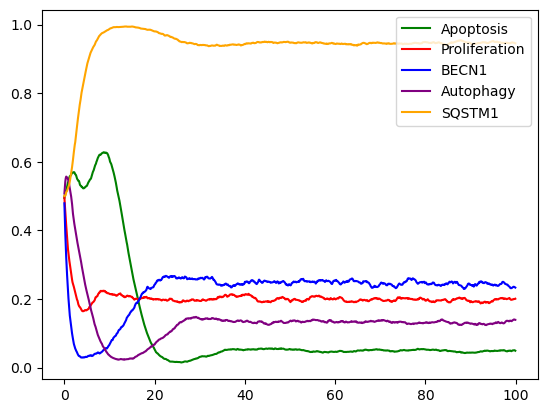

In [11]:
run_WT_allinputs.plot_node_trajectory()

Conclusion: this section shows that there is indeed a big limit cycle (or several limit cycles) that lead to apoptosis. What we see with the stable states of the Boolean model does not necessarily means that there exists only one phenotypic outcome with this model and the different contexts it simulates

## 5. Fixed point analysis

In [12]:
#run_WT_allinputs.plot_fixpoint()

In [13]:
run_WT_allinputs.get_last_nodes_probtraj()


,Apoptosis,Autophagy,BECN1,Proliferation,SQSTM1
99.9000,0.049355,0.139426,0.233384,0.200861,0.945446


In [14]:
run_WT_allinputs.get_last_states_probtraj()

,<nil>,Apoptosis,Apoptosis -- Autophagy,Apoptosis -- Proliferation -- Autophagy,Apoptosis -- Proliferation -- SQSTM1,Apoptosis -- Proliferation -- SQSTM1 -- Autophagy,Apoptosis -- SQSTM1,Apoptosis -- SQSTM1 -- Autophagy,Apoptosis -- SQSTM1 -- BECN1,Autophagy,BECN1,BECN1 -- Autophagy,Proliferation,Proliferation -- Autophagy,Proliferation -- BECN1,Proliferation -- BECN1 -- Autophagy,Proliferation -- SQSTM1,Proliferation -- SQSTM1 -- Autophagy,Proliferation -- SQSTM1 -- BECN1,Proliferation -- SQSTM1 -- BECN1 -- Autophagy,SQSTM1,SQSTM1 -- Autophagy,SQSTM1 -- BECN1,SQSTM1 -- BECN1 -- Autophagy
99.9000,0.003878,0.0002,0.002676,0.000217,0.009156,0.0002,0.033847,0.002459,0.0006,0.027065,0.00088,0.011966,0.001153,0.005119,0.0002,0.0012,0.149825,0.016747,0.01568,0.001364,0.463107,0.050967,0.182048,0.019446


In [15]:
fp_table = run_WT_allinputs.get_fptable()
print(fp_table)

None


In [16]:
#run_WT_allinputs.plot_fixpoint()

This section confirms the conclusion of the previous one.

## 6. Simulate Four Scenarios and Visualize Outputs

The four classical stress scenarios validated against the literature:

| Scenario | Inputs set to ON |
|---|---|
| Growth-factor stimulation | `Growth_factor`, `Insuline` |
| Amino-acid starvation | `AA_Starvation` |
| ER stress / glucose starvation | `Glucose_starv` |
| Oxidative stress | `O_stress` |

For each, we track the full time-course probability of `Proliferation`, `Apoptosis` and `BECN1` to visualize the biphasic autophagy-then-apoptosis switch (or its absence, for the growth-factor scenario).

We additionally tested three scenarios with TNF or death receptor engagement that should trigger death. 

In [17]:
# 4 SCENARIOS with different initial conditions

GrowthFactorStimulation = {"Growth_factor": 1, "Insuline": 1}
AminoAcidStarvation = {"AA_Starvation": 1}
ERstressGlucoseStarvation = {"Glucose_starv": 1}
OxidativeStress = {"O_stress": 1}


Text(0.5, 0.98, 'WT simulations for the GF stimulation')

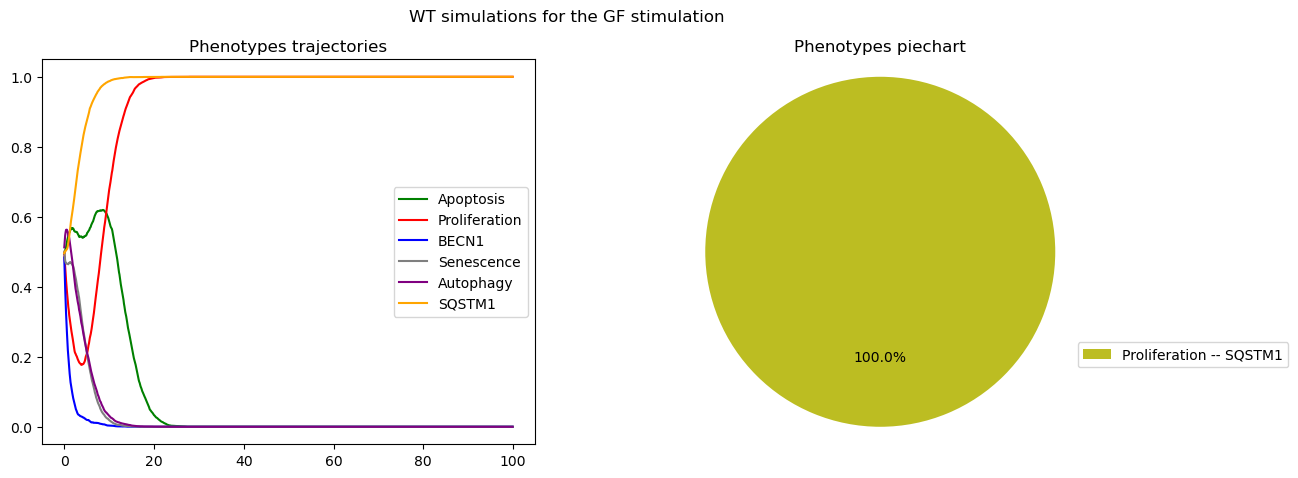

In [18]:
# SCENARIO 1

model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "SQSTM1", "Autophagy", "Senescence"))
#model_maboss.network.set_output(("O_stress", "Growth_factor", "Glucose_starv", "AA_Starvation", "TNF_R_or_DR", "Insuline"))

WT_GF = model_maboss.copy()
maboss.set_nodes_istate(WT_GF, GrowthFactorStimulation, [0,1])
run_WT_GF = WT_GF.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_GF.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_GF.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the GF stimulation")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')


* SQSTM1=1 literally means Atphgo_mat=0, thus, autophagy never reached the mature stage.
* Apoptosis + SQSTM1, Autophagy low/off → death occurred essentially without autophagy involvement, through the unguarded route.
* Apoptosis + SQSTM1 + Autophagy_sustained → death occurred because of repeatedly failed autophagy, the specific mechanism this network encodes for "autophagy can also drive apoptosis."
* Apoptosis=1 together with SQSTM1=1 means the cell committed to death via the "default," unprotected pathway

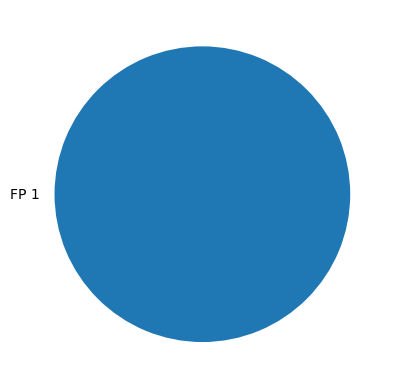

In [19]:
run_WT_GF.plot_fixpoint()

Text(0.5, 0.98, 'WT simulations for the AA starvation')

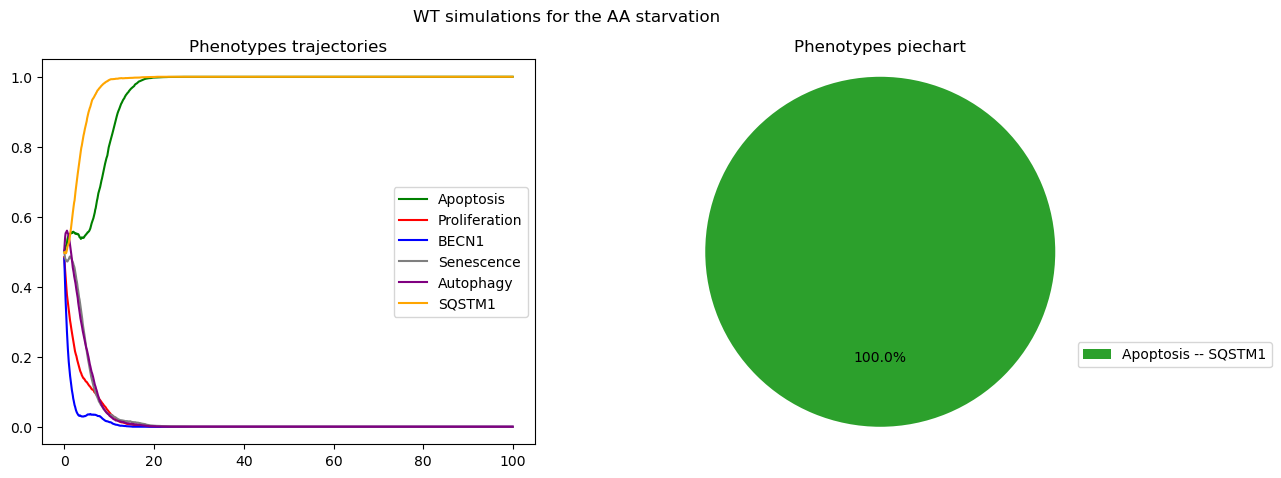

In [20]:
# SCENARIO 2

GrowthFactorStimulation = {"Growth_factor": 1, "Insuline": 1}
AminoAcidStarvation = {"AA_Starvation": 1}
ERstressGlucoseStarvation = {"Glucose_starv": 1}
OxidativeStress = {"O_stress": 1}

#model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_AA = model_maboss.copy()
maboss.set_nodes_istate(WT_AA, AminoAcidStarvation, [0,1])
run_WT_AA = WT_AA.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_AA.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_AA.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the AA starvation")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')


In [21]:
#run_WT_AA.plot_fixpoint()

Text(0.5, 0.98, 'WT simulations for the ER starvation')

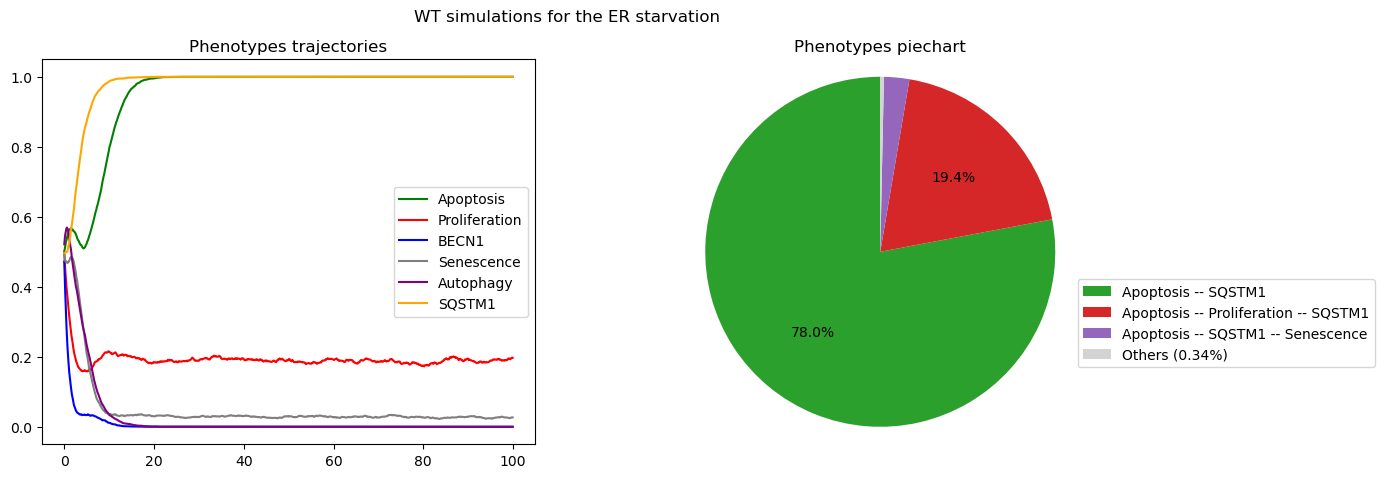

In [22]:
# SCENARIO 3

GrowthFactorStimulation = {"Growth_factor": 1, "Insuline": 1}
AminoAcidStarvation = {"AA_Starvation": 1}
ERstressGlucoseStarvation = {"Glucose_starv": 1}
OxidativeStress = {"O_stress": 1}

#model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_ER = model_maboss.copy()
maboss.set_nodes_istate(WT_ER, ERstressGlucoseStarvation, [0,1])
run_WT_ER = WT_ER.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_ER.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_ER.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the ER starvation")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')


In [23]:
#run_WT_ER.plot_fixpoint()

Text(0.5, 0.98, 'WT simulations for the OS')

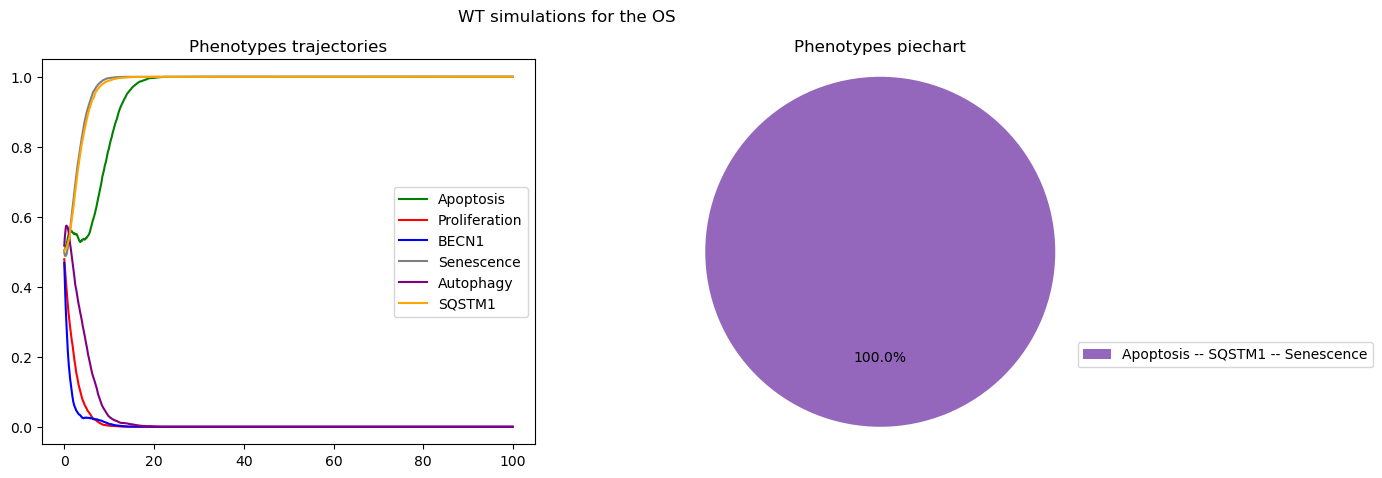

In [24]:
# SCENARIO 4

GrowthFactorStimulation = {"Growth_factor": 1, "Insuline": 1}
AminoAcidStarvation = {"AA_Starvation": 1}
ERstressGlucoseStarvation = {"Glucose_starv": 1}
OxidativeStress = {"O_stress": 1}

#model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_OS = model_maboss.copy()
maboss.set_nodes_istate(WT_OS, OxidativeStress, [0,1])
run_WT_OS = WT_OS.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_OS.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_OS.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the OS")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')

Text(0.5, 0.98, 'WT simulations for the TNF')

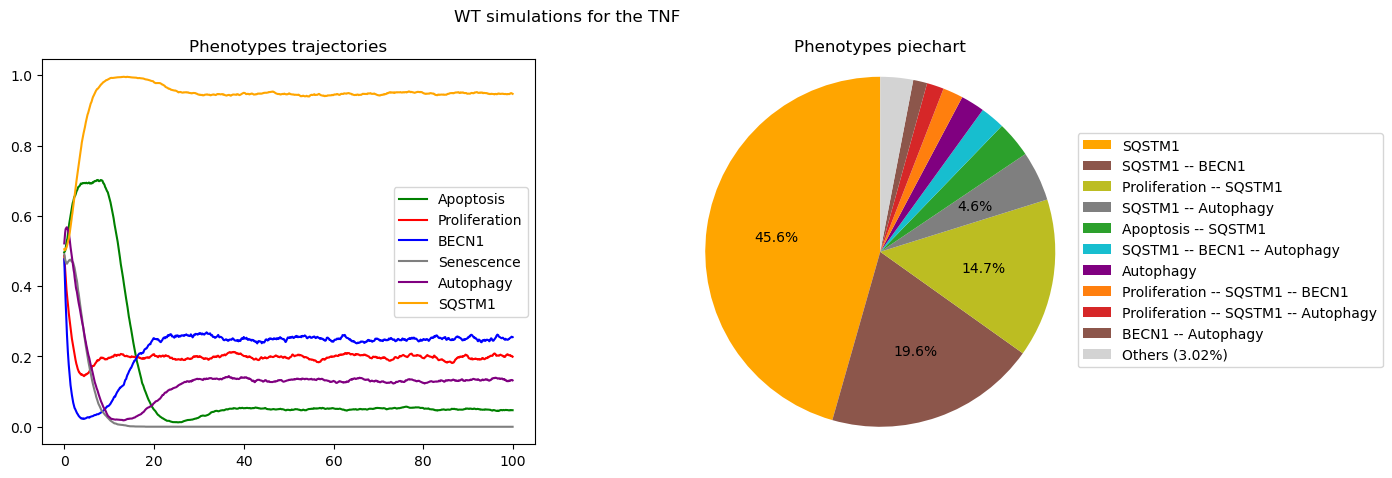

In [25]:
# SCENARIO 5
# expected outcome: Isolated TNF signaling is pro-survival (NF-κB) unless co-stimulated (Micheau & Tschopp 2003)

TNF_death = {"TNF_R_or_DR": 1}
TNF_OS = {"TNF_R_or_DR": 1, "O_stress": 1}
SevereConditions = {"Glucose_starv": 1, "O_stress": 1, "AA_Starvation": 1}


#model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_TNF = model_maboss.copy()
maboss.set_nodes_istate(WT_TNF, TNF_death, [0,1])
run_WT_TNF = WT_TNF.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_TNF.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_TNF.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the TNF")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')

In [26]:
#run_WT_TNF.plot_fixpoint()

Text(0.5, 0.98, 'WT simulations for the TNF & oxidative stress')

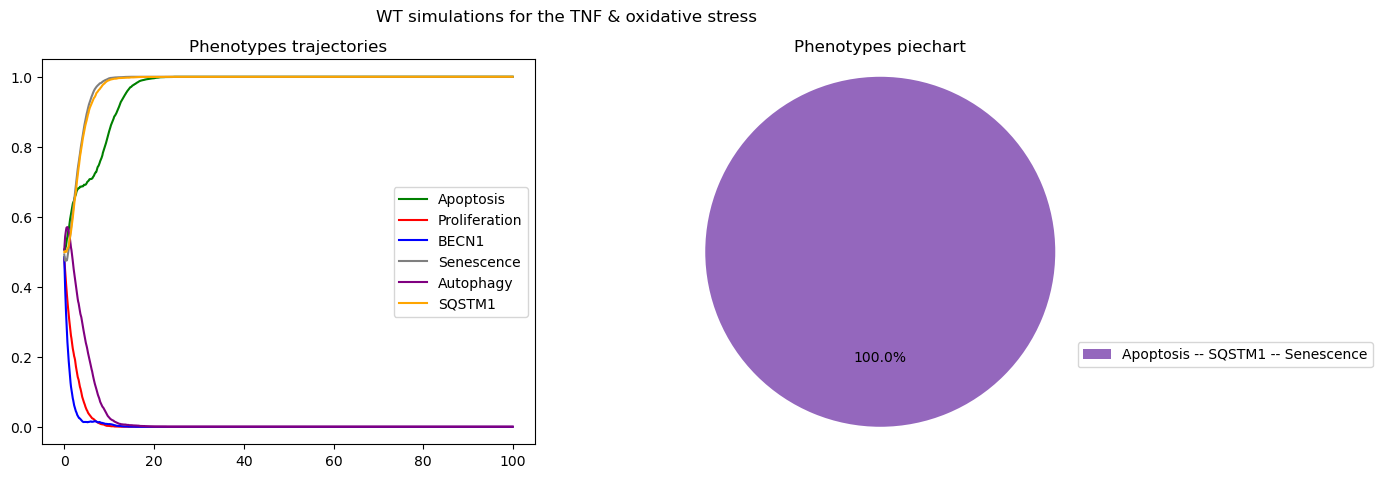

In [27]:
# SCENARIO 6
# expected outcome: Combined insults (“second hit”) switch outcome to death

TNF_death = {"TNF_R_or_DR": 1}
TNF_OS = {"TNF_R_or_DR": 1, "O_stress": 1}
SevereConditions = {"Glucose_starv": 1, "O_stress": 1, "AA_Starvation": 1}


#model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_TNF_OS = model_maboss.copy()
maboss.set_nodes_istate(WT_TNF_OS, TNF_OS, [0,1])
run_WT_TNF_OS = WT_TNF_OS.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_TNF_OS.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_TNF_OS.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the TNF & oxidative stress")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')

Text(0.5, 0.98, 'WT simulations for the SC')

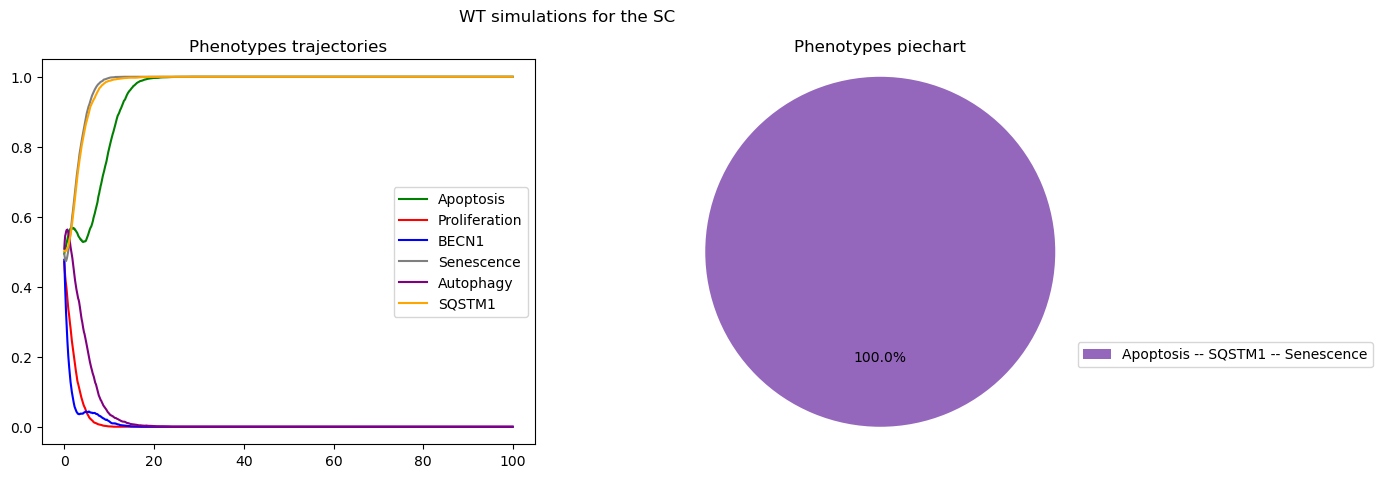

In [28]:
# SCENARIO 7
# expected outcome: Multiple concurrent stresses overwhelm adaptive capacity → death

TNF_death = {"TNF_R_or_DR": 1}
TNF_OS = {"TNF_R_or_DR": 1, "O_stress": 1}
SevereConditions = {"Glucose_starv": 1, "O_stress": 1, "AA_Starvation": 1}


#model_maboss.network.set_output(("Apoptosis", "Proliferation", "BECN1", "Autop_digestion", "Autophagy", "Senescence"))


WT_SC = model_maboss.copy()
maboss.set_nodes_istate(WT_SC, SevereConditions, [0,1])
run_WT_SC = WT_SC.run()

# Define a figure to host the trajectories and the pie-chart side by side 
fig, axes = plt.subplots(1,2, figsize=(14,5)) #colonnes, lignes

# Plot the phenotype trajectories
run_WT_SC.plot_node_trajectory(axes=axes[0])
axes[0].set_title('Phenotypes trajectories')

# Plot pie chart
run_WT_SC.plot_piechart(axes=axes[1])
axes[1].set_title('Phenotypes piechart')

plt.suptitle("WT simulations for the SC")

## You may want to save the figure with the following instructions:
# figure = run_WT_allinputs.get_states_probtraj().plot()
# save_figure(figure, 'WT')

## 7. Simulate `BECN1` Mutations (ON / OFF)

`BECN1` (Beclin1) is hypothesized to act as the death/survival switch. We force it permanently `ON` or `OFF` (`simulate_mutation`-equivalent via `copy_and_mutate`) on top of each of the four scenarios above, and compare the final `Apoptosis` / `Proliferation` / `Autop_digestion` probabilities to the wild-type (free `BECN1`) run.

Text(0.5, 0.98, 'BECN1 KO simulations')

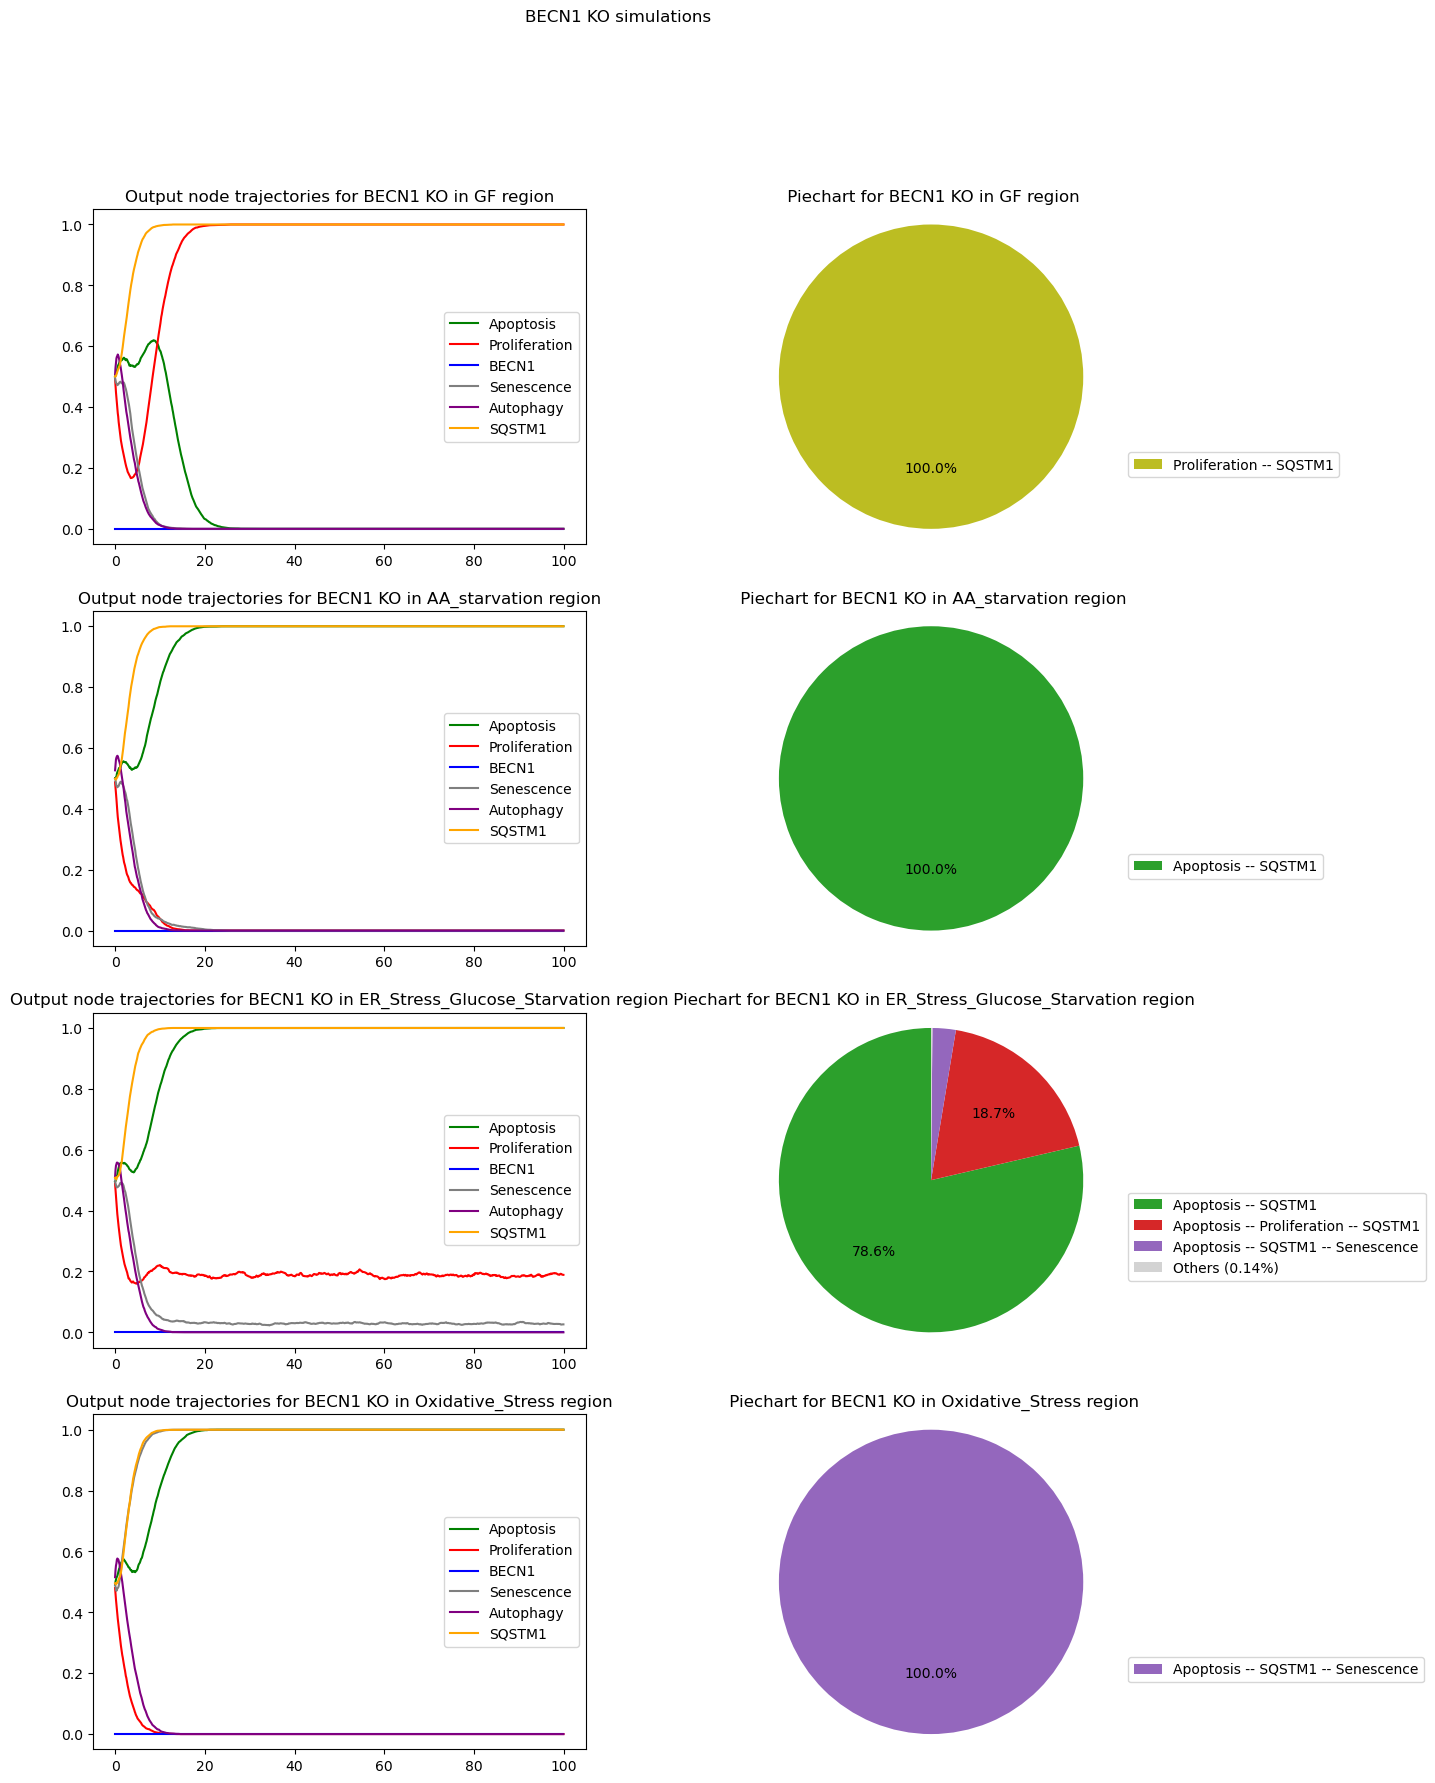

In [29]:
# Setting a figure encompassing four panels: with time plots and pie charts side by side,
# and the results for the four region input combinations over four rows.
fig, axes = plt.subplots(4,2, figsize=(14,20))
figrow=0  # integer for the iteration over the four regions (rows)
regions=['GF','AA_starvation','ER_Stress_Glucose_Starvation','Oxidative_Stress']

for init in [GrowthFactorStimulation,AminoAcidStarvation,ERstressGlucoseStarvation,OxidativeStress]:
    BECN1_KO_maboss = model_maboss.copy()
    BECN1_KO_maboss.mutate("BECN1", "OFF")
    maboss.set_nodes_istate(BECN1_KO_maboss, init, [0,1])
    BECN1_KO = BECN1_KO_maboss.run()
    BECN1_KO.plot_node_trajectory(axes=axes[figrow,0])
    axes[figrow,0].set_title(f"Output node trajectories for BECN1 KO in {regions[figrow]} region")
    BECN1_KO.plot_piechart(axes=axes[figrow,1])
    axes[figrow,1].set_title(f" Piechart for BECN1 KO in {regions[figrow]} region")
    figrow+=1

plt.suptitle("BECN1 KO simulations")


Text(0.5, 0.98, 'BECN1 KI simulations')

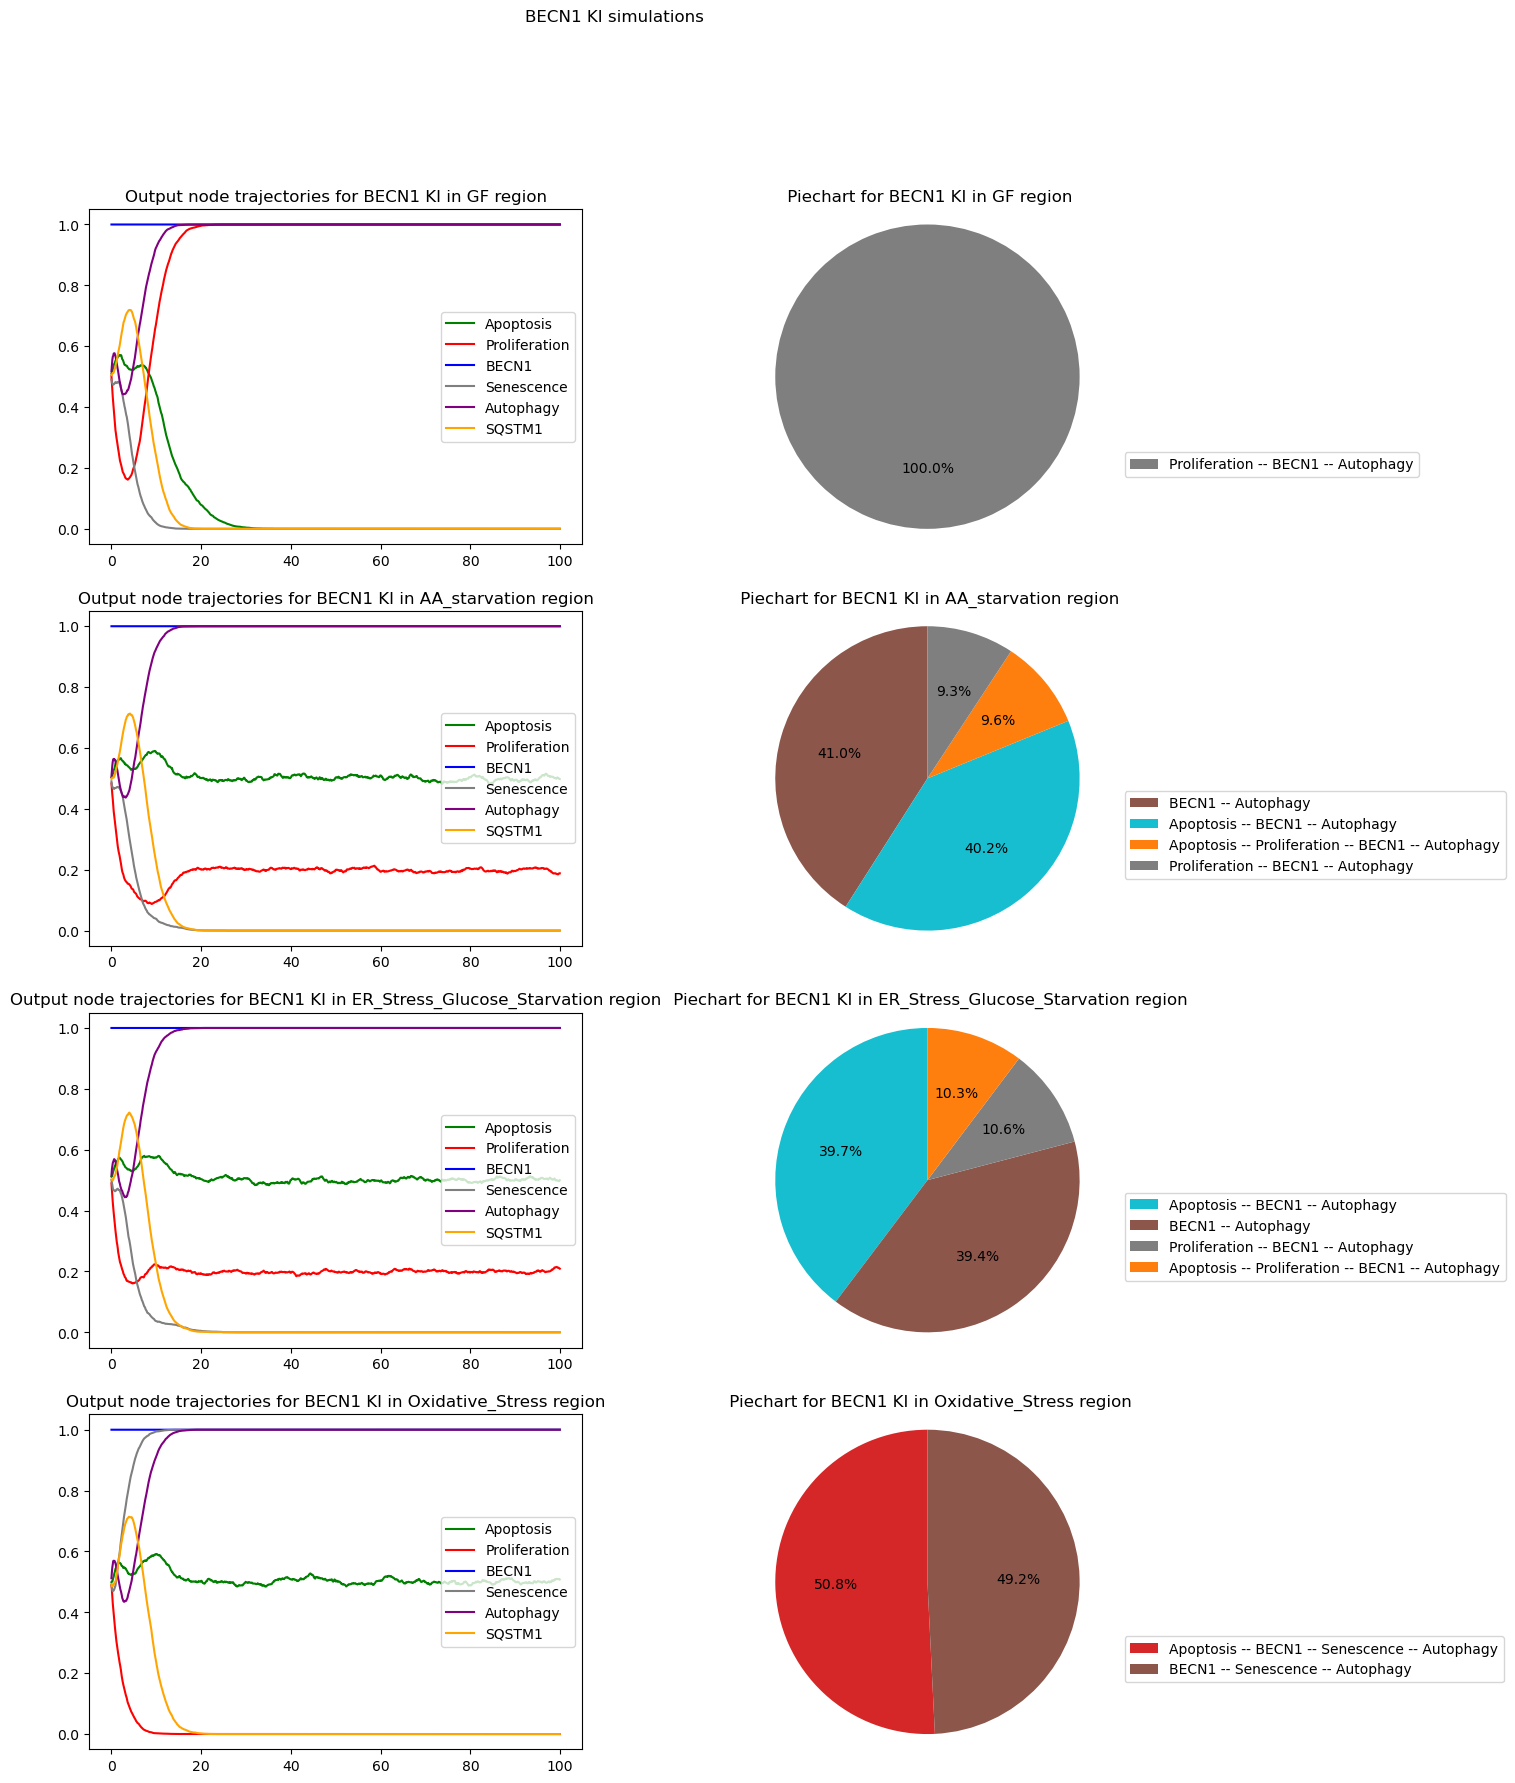

In [30]:
# Setting a figure encompassing four panels: with time plots and pie charts side by side,
# and the results for the four region input combinations over four rows.
fig, axes = plt.subplots(4,2, figsize=(14,20))
figrow=0  # integer for the iteration over the four regions (rows)
regions=['GF','AA_starvation','ER_Stress_Glucose_Starvation','Oxidative_Stress']

for init in [GrowthFactorStimulation,AminoAcidStarvation,ERstressGlucoseStarvation,OxidativeStress]:
    BECN1_KI_maboss = model_maboss.copy()
    BECN1_KI_maboss.mutate("BECN1", "ON")
    maboss.set_nodes_istate(BECN1_KI_maboss, init, [0,1])
    BECN1_KI = BECN1_KI_maboss.run()
    BECN1_KI.plot_node_trajectory(axes=axes[figrow,0])
    axes[figrow,0].set_title(f"Output node trajectories for BECN1 KI in {regions[figrow]} region")
    BECN1_KI.plot_piechart(axes=axes[figrow,1])
    axes[figrow,1].set_title(f" Piechart for BECN1 KI in {regions[figrow]} region")
    figrow+=1

plt.suptitle("BECN1 KI simulations")


BECN1 OFF has no impact. However, forcing BECN1 to be active switches the phenotype towards an autphagy one. 

## 8. Simulate mTOR treatment (rapamycin)

Text(0.5, 0.98, 'mTOR KO simulations')

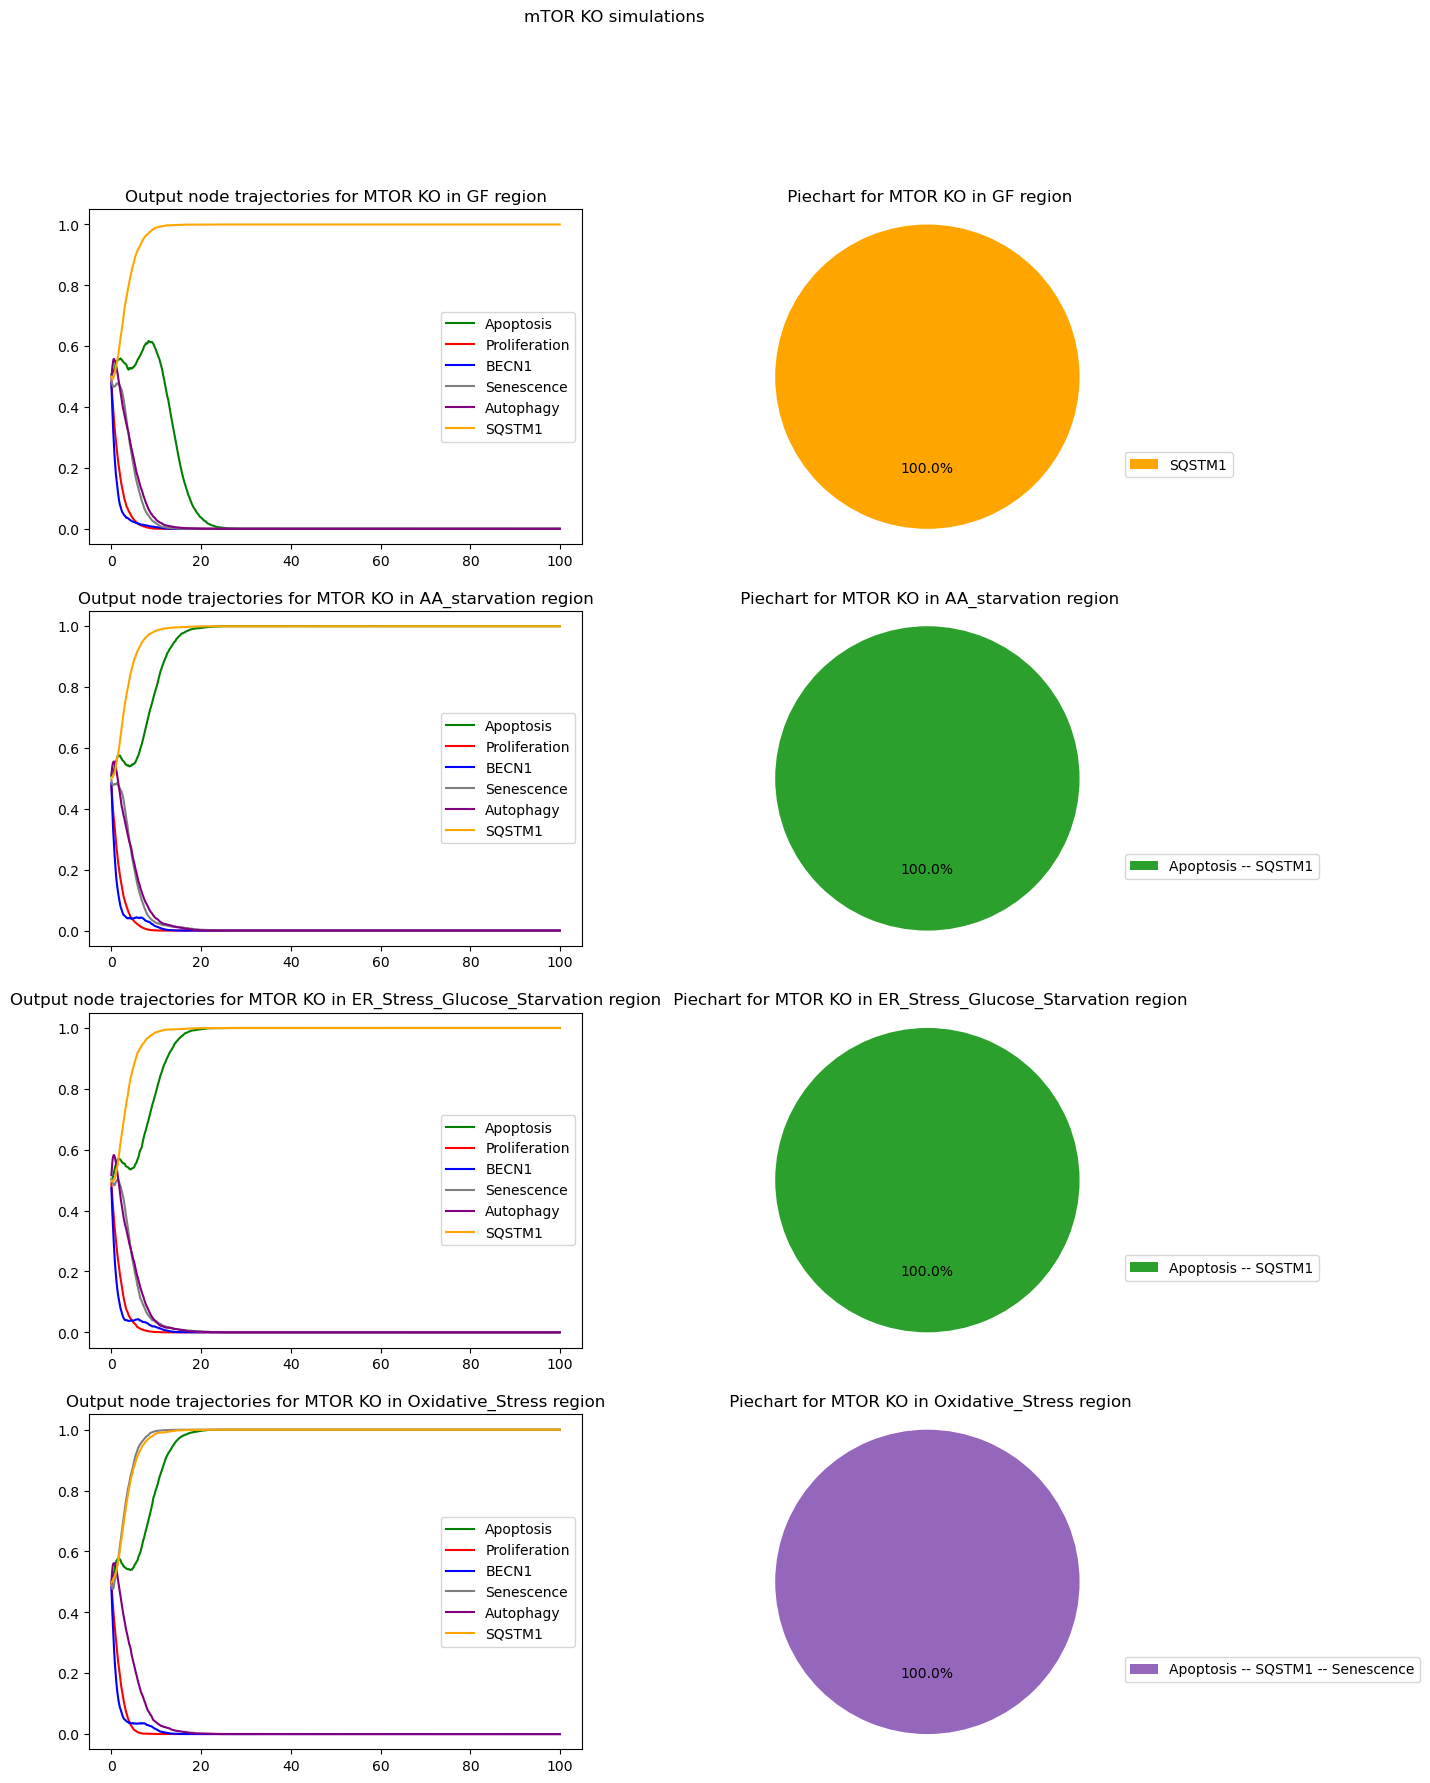

In [31]:
# Setting a figure encompassing four panels: with time plots and pie charts side by side,
# and the results for the four region input combinations over four rows.
fig, axes = plt.subplots(4,2, figsize=(14,20))
figrow=0  # integer for the iteration over the four regions (rows)
regions=['GF','AA_starvation','ER_Stress_Glucose_Starvation','Oxidative_Stress']

for init in [GrowthFactorStimulation,AminoAcidStarvation,ERstressGlucoseStarvation,OxidativeStress]:
    MTOR_KO_maboss = model_maboss.copy()
    MTOR_KO_maboss.mutate("MTOR", "OFF")
    maboss.set_nodes_istate(MTOR_KO_maboss, init, [0,1])
    MTOR_KO = MTOR_KO_maboss.run()
    MTOR_KO.plot_node_trajectory(axes=axes[figrow,0])
    axes[figrow,0].set_title(f"Output node trajectories for MTOR KO in {regions[figrow]} region")
    MTOR_KO.plot_piechart(axes=axes[figrow,1])
    axes[figrow,1].set_title(f" Piechart for MTOR KO in {regions[figrow]} region")
    figrow+=1

plt.suptitle("mTOR KO simulations")


Conclusion: mTOR inhibition leads to a full apoptotic phenotype when subjected to stress. Otherwise, blocking mTOR shuts off the proliferation arm directly, but doesn't by itself create an apoptotic signal — apoptosis in this network requires an actual stress input. So "no stress + mTOR off + growth factor present" landing on quiescence rather than death is exactly what the clinical mTOR-inhibitor picture would predict: cytostasis, not cytotoxicity, unless combined with an added insult (doi: 10.1371/journal.pone.0099927, doi: 10.12688/f1000research.9207.1, doi: 10.3390/ijms22158019).

## 9. Compare Mutation Results Across Scenarios

Grouped bar charts of final `Apoptosis` and `Proliferation` probability, for WT / `BECN1`-ON / `BECN1`-OFF, in each of the four scenarios.

In [32]:
# [2026-09-18] Cleaned up: this cell used to contain two conflicting definitions of
# make_simulation. Only the second one was ever actually in effect (Python keeps the
# last definition of a name in a cell), and it already randomized every node before
# fixing the inputs -- kept and clarified below, duplicate removed.
SCENARIOS = {
    "Growth-factor stimulation": {"Growth_factor": 1, "Insuline": 1},
    "Amino-acid starvation": {"AA_Starvation": 1},
    "ER stress / glucose starvation": {"Glucose_starv": 1},
    "Oxidative stress": {"O_stress": 1},
}

def make_simulation(overrides=None, max_time=60, sample_count=3000, time_tick=0.5):
    """Fresh simulation: every node starts random (0.5/0.5) EXCEPT the context-defining
    inputs (BASE_INPUTS, plus any scenario-specific overrides), which are fixed
    deterministically -- these are "the inputs that correspond to different contexts"."""
    sim = biolqm.to_maboss(model_biolqm)
    sim.update_parameters(max_time=max_time, sample_count=sample_count, time_tick=time_tick, thread_count=4)
    for n in sim.network:
        sim.network.set_istate(n, [0.5, 0.5])
    inputs = dict(BASE_INPUTS)
    if overrides:
        inputs.update(overrides)
    for node, val in inputs.items():
        sim.network.set_istate(node, [1 - val, val])
    sim.network.set_output(OUTPUT_NODES)
    return sim


def run_mutant(overrides, mutation, max_time=60, sample_count=2000):
    """mutation: 'WT' (free BECN1), 'ON' (locked) or 'OFF' (knocked out)."""
    sim = make_simulation(overrides, max_time=max_time, sample_count=sample_count)
    if mutation in ("ON", "OFF"):
        sim.mutate("BECN1", mutation)
    res = sim.run()
    last = res.get_last_nodes_probtraj().iloc[0]
    return last.reindex(OUTPUT_NODES).fillna(0.0)


mutation_results = {}
for name, overrides in SCENARIOS.items():
    for mutation in ["WT", "ON", "OFF"]:
        mutation_results[(name, mutation)] = run_mutant(overrides, mutation)

mutation_df = pd.DataFrame(mutation_results).T
mutation_df.index.names = ["scenario", "BECN1 mutation"]
mutation_df


Apoptosis  Proliferation  \
scenario                       BECN1 mutation                             
Growth-factor stimulation      WT               0.000000       1.000000   
                               ON               0.000000       1.000000   
                               OFF              0.000000       1.000000   
Amino-acid starvation          WT               1.000000       0.000000   
                               ON               0.497647       0.194804   
                               OFF              1.000000       0.000000   
ER stress / glucose starvation WT               0.999999       0.191173   
                               ON               0.502369       0.191014   
                               OFF              0.999999       0.170161   
Oxidative stress               WT               1.000000       0.000000   
                               ON               0.501266       0.000000   
                               OFF              1.000000       0.000000   

                                               BECN1  Autop_digestion  \
scenario                       BECN1 mutation                           
Growth-factor stimulation      WT                0.0              0.0   
                               ON                1.0              1.0   
                               OFF               0.0              0.0   
Amino-acid starvation          WT                0.0              0.0   
                               ON                1.0              1.0   
                               OFF               0.0              0.0   
ER stress / glucose starvation WT                0.0              0.0   
                               ON                1.0              1.0   
                               OFF               0.0              0.0   
Oxidative stress               WT                0.0              0.0   
                               ON                1.0              1.0   
                               OFF               0.0              0.0   

                                               Autophagy  Senescence    SQSTM1  
scenario                       BECN1 mutation                                   
Growth-factor stimulation      WT                    0.0    0.000000  1.000000  
                               ON                    1.0    0.000000  0.000000  
                               OFF                   0.0    0.000000  1.000000  
Amino-acid starvation          WT                    0.0    0.000000  1.000000  
                               ON                    1.0    0.000000  0.000000  
                               OFF                   0.0    0.000000  1.000000  
ER stress / glucose starvation WT                    0.0    0.023216  0.999999  
                               ON                    1.0    0.000000  0.000000  
                               OFF                   0.0    0.029808  0.999999  
Oxidative stress               WT                    0.0    1.000000  1.000000  
                               ON                    1.0    1.000000  0.000000  
                               OFF                   0.0    1.000000  1.000000

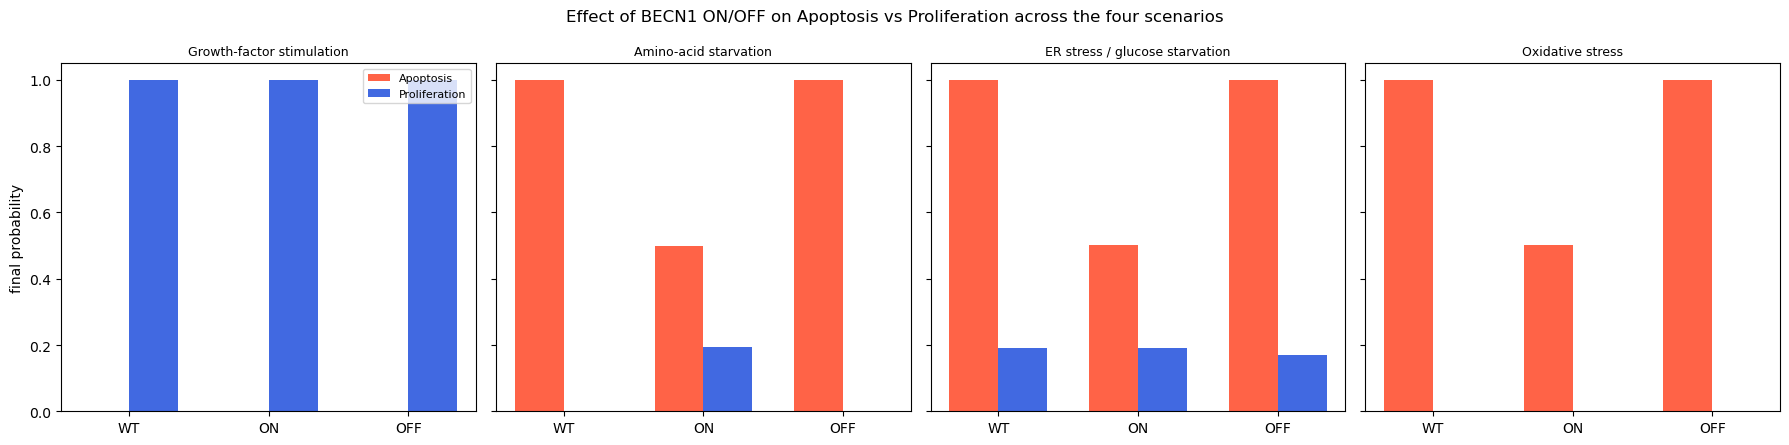

In [33]:
mutation_order = ["WT", "ON", "OFF"]
width = 0.35

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, name in zip(axes, SCENARIOS):
    sub = mutation_df.loc[name].loc[mutation_order]
    x = range(len(mutation_order))
    ax.bar([i - width / 2 for i in x], sub["Apoptosis"], width, label="Apoptosis", color="tomato")
    ax.bar([i + width / 2 for i in x], sub["Proliferation"], width, label="Proliferation", color="royalblue")
    ax.set_xticks(list(x))
    ax.set_xticklabels(mutation_order)
    ax.set_title(name, fontsize=9)
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("final probability")
axes[0].legend(fontsize=8)
plt.suptitle("Effect of BECN1 ON/OFF on Apoptosis vs Proliferation across the four scenarios")
plt.tight_layout()
plt.show()


In [34]:
mutation_results = {}
for name, overrides in SCENARIOS.items():
    for mutation in ["WT", "OFF"]:
        mutation_results[(name, mutation)] = run_mutant(overrides, mutation)

mutation_df = pd.DataFrame(mutation_results).T
mutation_df.index.names = ["scenario", "MTOR mutation"]
mutation_df
SCENARIOS = {
    "Growth-factor stimulation": {"Growth_factor": 1, "Insuline": 1},
    "Amino-acid starvation": {"AA_Starvation": 1},
    "ER stress / glucose starvation": {"Glucose_starv": 1},
    "Oxidative stress": {"O_stress": 1},
}

def run_mutant(overrides, mutation, max_time=60, sample_count=2000):
    """mutation: 'WT', 'OFF' (knocked out)."""
    sim = make_simulation(overrides, max_time=max_time, sample_count=sample_count)
    if mutation in ("OFF"):
        sim.mutate("MTOR", mutation)
    res = sim.run()
    last = res.get_last_nodes_probtraj().iloc[0]
    return last.reindex(OUTPUT_NODES).fillna(0.0)


mutation_results = {}
for name, overrides in SCENARIOS.items():
    for mutation in ["WT", "OFF"]:
        mutation_results[(name, mutation)] = run_mutant(overrides, mutation)

mutation_df = pd.DataFrame(mutation_results).T
mutation_df.index.names = ["scenario", "mTOR mutation"]
mutation_df


Apoptosis  Proliferation  BECN1  \
scenario                       mTOR mutation                                    
Growth-factor stimulation      WT              0.000000       1.000000    0.0   
                               OFF             0.000000       0.000000    0.0   
Amino-acid starvation          WT              1.000000       0.000000    0.0   
                               OFF             1.000000       0.000000    0.0   
ER stress / glucose starvation WT              1.000001       0.184889    0.0   
                               OFF             1.000000       0.000000    0.0   
Oxidative stress               WT              1.000000       0.000000    0.0   
                               OFF             1.000000       0.000000    0.0   

                                              Autop_digestion  Autophagy  \
scenario                       mTOR mutation                               
Growth-factor stimulation      WT                         0.0        0.0   
                               OFF                        0.0        0.0   
Amino-acid starvation          WT                         0.0        0.0   
                               OFF                        0.0        0.0   
ER stress / glucose starvation WT                         0.0        0.0   
                               OFF                        0.0        0.0   
Oxidative stress               WT                         0.0        0.0   
                               OFF                        0.0        0.0   

                                              Senescence    SQSTM1  
scenario                       mTOR mutation                        
Growth-factor stimulation      WT                0.00000  1.000000  
                               OFF               0.00000  1.000000  
Amino-acid starvation          WT                0.00000  1.000000  
                               OFF               0.00000  1.000000  
ER stress / glucose starvation WT                0.03335  1.000001  
                               OFF               0.00000  1.000000  
Oxidative stress               WT                1.00000  1.000000  
                               OFF               1.00000  1.000000

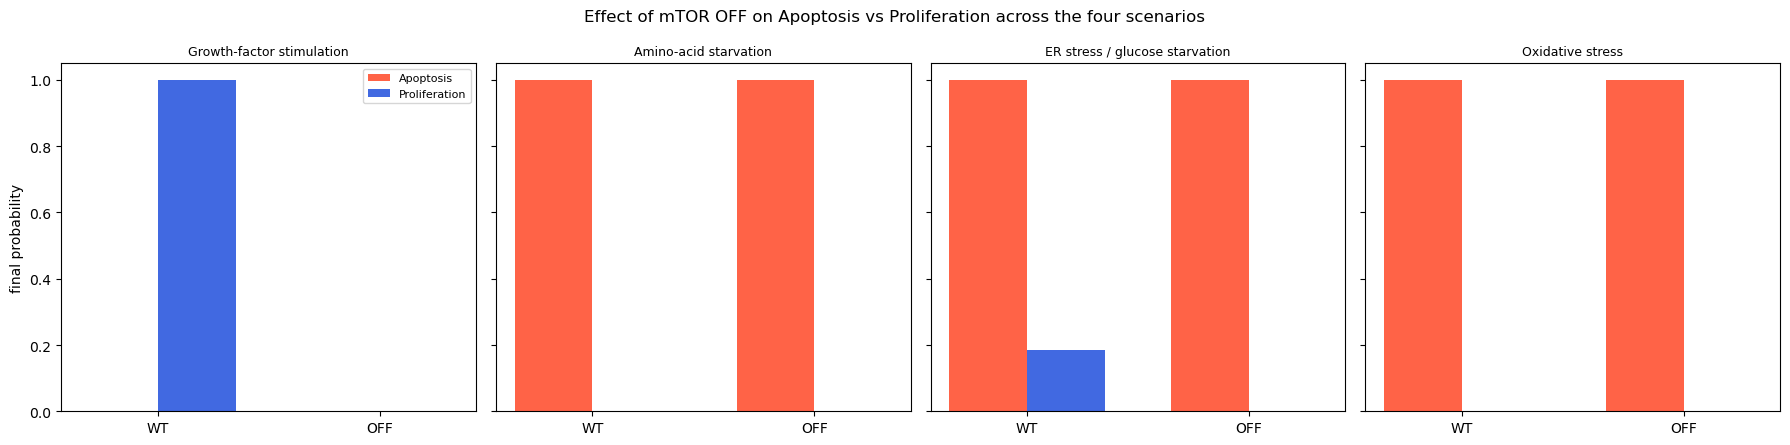

In [35]:
mutation_order = ["WT", "OFF"]
width = 0.35

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
for ax, name in zip(axes, SCENARIOS):
    sub = mutation_df.loc[name].loc[mutation_order]
    x = range(len(mutation_order))
    ax.bar([i - width / 2 for i in x], sub["Apoptosis"], width, label="Apoptosis", color="tomato")
    ax.bar([i + width / 2 for i in x], sub["Proliferation"], width, label="Proliferation", color="royalblue")
    ax.set_xticks(list(x))
    ax.set_xticklabels(mutation_order)
    ax.set_title(name, fontsize=9)
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("final probability")
axes[0].legend(fontsize=8)
plt.suptitle("Effect of mTOR OFF on Apoptosis vs Proliferation across the four scenarios")
plt.tight_layout()
plt.show()


Problem with this last figure ==> GF in mTOR OFF is fully apoptotic... 

## 9. Conclusion


A question that we need to address is what we see here is at the level of individual cells. We cannot conclude whether it is beneficial or not for cancer. However, we can start thinking about what would happen if we use a population of cells. Would some cells die for the benefit of the population? How many? 

## 10. Model extension: new phenotype markers and a genotoxic-stress input

6 new nodes were added to better characterize autophagy. 2 rules were modified to include these new nodes. 

| Node | Logic | Rationale |
|---|---|---|
| `Autophagy` | `Atphgo_form \| Atphgo_mat` | Composite phenotype output, mirrored on `Apoptosis`/`Proliferation`: autophagy machinery engaged, from formation onward. Deliberately broader than `Autop_digestion`, which is currently logically identical to `Atphgo_mat` (a single-parent passthrough) — worth knowing if you were treating them as independent readouts. |
| `SQSTM1` | `!Autop_digestion` | p62/SQSTM1: the clinical/experimental readout that resolves whether LC3-II accumulation means active induction or a downstream flux block. Accumulates when degradation isn't happening, cleared once flux completes. |
| `DNA_damage` | input (like `O_stress`) | Genotoxic stress (chemo/radiotherapy), now separable from generic oxidative stress. |
| `ATM` (extended) | `O_stress \| DNA_damage` | Purely additive: the existing `O_stress` route is untouched, `DNA_damage` adds a second, independent trigger. |
| `CDKN2A` (p16INK4a) | `ATM` | Senescence marker, driven by persistent DNA-damage/oncogenic-stress signaling, largely independent of the p21/MDM2 arm (Kuilman 2010; Gorgoulis 2019). |
| `p21_sustained` | `p21` | Persistence proxy for p21, same pattern the model already uses for `CHOP_sustained`/`SP1_sustained`: distinguishes a durable p21 signal from a transient checkpoint blip. |
| `pRB` (extended) | `p21 \| CDKN2A` | Purely additive: adds the p16/RB senescence branch alongside the existing p21 branch. |
| `Senescence` | `(pRB & p21_sustained) \| (pRB & CDKN2A)` | Composite phenotype output, mirrored on `Apoptosis`/`Proliferation`/`Autophagy`: durable RB-mediated arrest, distinguished from a transient cell-cycle checkpoint by requiring a *sustained* driver. |


## 11. Early- vs. late-stage autophagy inhibition

Autophagy inhibitors used or trialled in oncology don't all act at the same step, and the difference matters clinically:
- **Early block** (3-methyladenine/wortmannin-like): `PIK3C3` (VPS34) OFF -- prevents autophagosome **nucleation** entirely.
- **Late block** (chloroquine/hydroxychloroquine-like): `RAB7A` OFF -- lets autophagosomes **form** but blocks fusion with the lysosome, so they accumulate undegraded.


In [36]:
autophagy_block_trajectories = {}
for label, mutation in [
    ("WT (no block)", None),
    ("Early block: PIK3C3-OFF", ("PIK3C3", "OFF")),
    ("Late/CQ-like block: RAB7A-OFF", ("RAB7A", "OFF")),
]:
    for scenario_name, overrides in SCENARIOS.items():
        sim = make_simulation(overrides, max_time=40, sample_count=2500, time_tick=1)
        if mutation:
            sim.mutate(*mutation)
        autophagy_block_trajectories[(scenario_name, label)] = sim.run().get_nodes_probtraj()


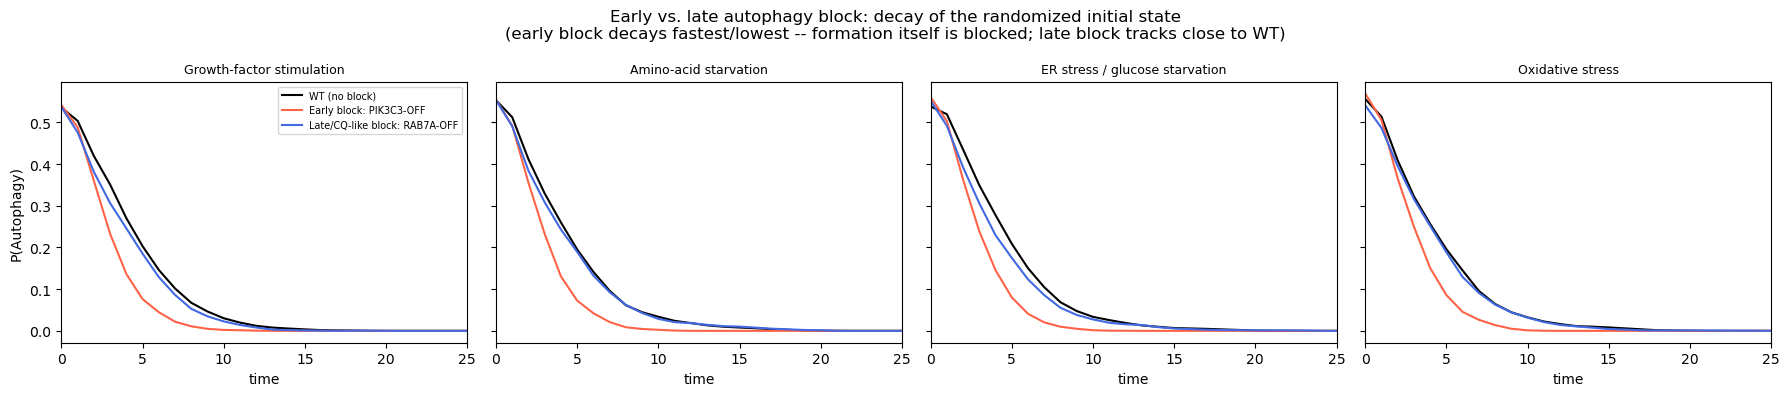

In [37]:
block_colors = {"WT (no block)": "black", "Early block: PIK3C3-OFF": "tomato", "Late/CQ-like block: RAB7A-OFF": "royalblue"}
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, scenario_name in zip(axes, SCENARIOS):
    for label, color in block_colors.items():
        traj = autophagy_block_trajectories[(scenario_name, label)]
        ax.plot(traj.index, traj["Autophagy"], label=label, color=color)
    ax.set_xlim(0, 25)
    ax.set_title(scenario_name, fontsize=9)
    ax.set_xlabel("time")
axes[0].set_ylabel("P(Autophagy)")
axes[0].legend(fontsize=7)
plt.suptitle("Early vs. late autophagy block: decay of the randomized initial state\n(early block decays fastest/lowest -- formation itself is blocked; late block tracks close to WT)")
plt.tight_layout()
plt.show()


In [38]:
# Fully-settled endpoint (t=40): by now Autophagy is 0 for all three conditions in every
# scenario -- the early/late distinction is a transient-decay effect (plot above), not a
# steady-state one. Apoptosis, in contrast, DOES have a stable, non-transient endpoint,
# and confirms the earlier finding: blocking autophagy (either way) does not change it.
final_rows = {}
for label in block_colors:
    for scenario_name in SCENARIOS:
        last = autophagy_block_trajectories[(scenario_name, label)].iloc[-1]
        final_rows[(scenario_name, label)] = last.reindex(OUTPUT_NODES).fillna(0.0)
final_autophagy_block_df = pd.DataFrame(final_rows).T
final_autophagy_block_df.index.names = ["scenario", "block"]
final_autophagy_block_df[["Apoptosis", "Autophagy", "Proliferation", "SQSTM1"]]


,,Apoptosis,Autophagy,Proliferation,SQSTM1
scenario,block,,,,
Growth-factor stimulation,WT (no block),0.0,0.0,1.000000,1.0
Amino-acid starvation,WT (no block),1.0,0.0,0.000000,1.0
ER stress / glucose starvation,WT (no block),1.0,0.0,0.188310,1.0
Oxidative stress,WT (no block),1.0,0.0,0.000000,1.0
Growth-factor stimulation,Early block: PIK3C3-OFF,0.0,0.0,1.000000,1.0
Amino-acid starvation,Early block: PIK3C3-OFF,1.0,0.0,0.000000,1.0
ER stress / glucose starvation,Early block: PIK3C3-OFF,1.0,0.0,0.181650,1.0
Oxidative stress,Early block: PIK3C3-OFF,1.0,0.0,0.000000,1.0
Growth-factor stimulation,Late/CQ-like block: RAB7A-OFF,0.0,0.0,1.000000,1.0


Conclusion: Early block drives Autophagy to exactly 0 in every stress scenario (nucleation genuinely abolished), while late block leaves Autophagy essentially at the WT level (autophagosomes still form, only fusion is blocked) — that's exactly the qualitative signature seen experimentally (3-MA/VPS34i reduce LC3 puncta; CQ/HCQ cause them to accumulate). Meanwhile, SQSTM1 saturates to ~1.0 under both blocks, also correctly — p62 accumulation doesn't care where the block is, only that flux doesn't complete. T

## 12. Oncogenic backgrounds under stress

Every scenario so far runs on a wild-type background. Real tumors carry recurrent lesions in exactly this network. Locking in a handful of the most common ones and re-running the 4 stress scenarios asks a more clinically relevant question: does a given oncogenic lesion **rescue** stressed cells from the autophagy-to-apoptosis switch, or does it just add proliferative drive on top of a fate the network still reaches?


In [39]:
ONCO_BACKGROUNDS = {
    "WT": {},
    "PTEN-OFF (PI3K/AKT hyperactive)": {"PTEN": "OFF"},
    "PIK3CA-ON (constitutive)": {"PIK3CA": "ON"},
    "TP53_nuc-OFF (p53 loss)": {"TP53_nuc": "OFF"},
    "MYC-ON (overexpression)": {"MYC": "ON"},
    "BCL2-ON (overexpression)": {"BCL2": "ON"},
}

onco_results = {}
for scenario_name, overrides in SCENARIOS.items():
    for onco_name, mutations in ONCO_BACKGROUNDS.items():
        sim = make_simulation(overrides, max_time=60, sample_count=2000)
        for node, mut in mutations.items():
            sim.mutate(node, mut)
        res = sim.run()
        last = res.get_last_nodes_probtraj().iloc[0]
        onco_results[(scenario_name, onco_name)] = last.reindex(OUTPUT_NODES).fillna(0.0)

onco_df = pd.DataFrame(onco_results).T
onco_df.index.names = ["scenario", "oncogenic background"]
onco_df[["Apoptosis", "Proliferation", "Senescence"]]


Apoptosis  \
scenario                       oncogenic background                         
Growth-factor stimulation      WT                                0.000000   
                               PTEN-OFF (PI3K/AKT hyperactive)   0.000000   
                               PIK3CA-ON (constitutive)          0.000000   
                               TP53_nuc-OFF (p53 loss)           0.000000   
                               MYC-ON (overexpression)           0.000000   
                               BCL2-ON (overexpression)          0.000000   
Amino-acid starvation          WT                                1.000000   
                               PTEN-OFF (PI3K/AKT hyperactive)   1.000000   
                               PIK3CA-ON (constitutive)          1.000000   
                               TP53_nuc-OFF (p53 loss)           1.000000   
                               MYC-ON (overexpression)           1.000000   
                               BCL2-ON (overexpression)          0.000000   
ER stress / glucose starvation WT                                0.999999   
                               PTEN-OFF (PI3K/AKT hyperactive)   1.000000   
                               PIK3CA-ON (constitutive)          1.000000   
                               TP53_nuc-OFF (p53 loss)           1.000000   
                               MYC-ON (overexpression)           1.000000   
                               BCL2-ON (overexpression)          0.000000   
Oxidative stress               WT                                1.000000   
                               PTEN-OFF (PI3K/AKT hyperactive)   1.000000   
                               PIK3CA-ON (constitutive)          1.000000   
                               TP53_nuc-OFF (p53 loss)           1.000000   
                               MYC-ON (overexpression)           1.000000   
                               BCL2-ON (overexpression)          0.000000   

                                                                Proliferation  \
scenario                       oncogenic background                             
Growth-factor stimulation      WT                                    1.000000   
                               PTEN-OFF (PI3K/AKT hyperactive)       1.000000   
                               PIK3CA-ON (constitutive)              1.000000   
                               TP53_nuc-OFF (p53 loss)               1.000000   
                               MYC-ON (overexpression)               1.000000   
                               BCL2-ON (overexpression)              1.000000   
Amino-acid starvation          WT                                    0.000000   
                               PTEN-OFF (PI3K/AKT hyperactive)       0.000000   
                               PIK3CA-ON (constitutive)              0.000000   
                               TP53_nuc-OFF (p53 loss)               0.000000   
                               MYC-ON (overexpression)               0.000000   
                               BCL2-ON (overexpression)              0.000000   
ER stress / glucose starvation WT                                    0.196434   
                               PTEN-OFF (PI3K/AKT hyperactive)       0.187305   
                               PIK3CA-ON (constitutive)              0.399720   
                               TP53_nuc-OFF (p53 loss)               0.201758   
                               MYC-ON (overexpression)               0.186092   
                               BCL2-ON (overexpression)              0.189623   
Oxidative stress               WT                                    0.000000   
                               PTEN-OFF (PI3K/AKT hyperactive)       0.000000   
                               PIK3CA-ON (constitutive)              0.000000   
                               TP53_nuc-OFF (p53 loss)               0.000000   
                               MYC-ON (overexpression)               0.000000   
                               BCL2-

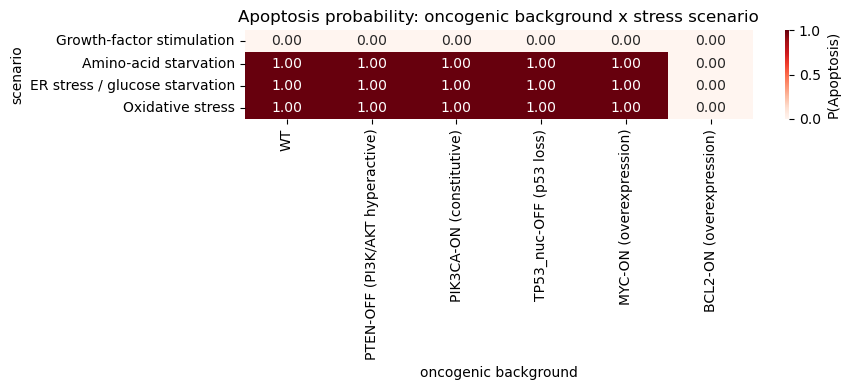

In [40]:
apoptosis_pivot = onco_df["Apoptosis"].unstack("oncogenic background").loc[list(SCENARIOS.keys()), list(ONCO_BACKGROUNDS.keys())]
plt.figure(figsize=(9, 4))
sns.heatmap(apoptosis_pivot, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, cbar_kws={"label": "P(Apoptosis)"})
plt.title("Apoptosis probability: oncogenic background x stress scenario")
plt.tight_layout()
plt.show()


## 13. Reversibility: is there a point of no return?

A biphasic autophagy-then-apoptosis kinetic (already visible in Section 6) suggests there's a window during which restoring growth factor could still rescue a starved cell before the death switch locks in. We test this with a two-stage protocol: run amino-acid starvation for a variable pulse duration, then switch to growth-factor-rich rescue conditions for the remainder of the simulation.

**Caveat (read before trusting the numbers):** MaBoSS does not natively support switching an input mid-trajectory within one continuous run, so stage 2 is re-seeded from stage 1's **marginal** (per-node, independent) probabilities at the checkpoint — a mean-field approximation that discards the correlation between which specific trajectories already committed to caspase activation and which didn't. It's a reasonable way to get a first-order answer ("is rescue possible at all, roughly how late"), but it will tend to blur out a sharp bimodal switch — treat it as a template to refine (e.g. with true piecewise-continuous inputs) rather than a validated rescue-timing curve.


In [41]:
RESEED_NODES = ["BECN1", "MTOR", "Caspase_3_6_7_C", "Cyt_C", "Caspase9_APAF1_C", "BAX",
                 "CHOP", "TP53_nuc", "TP53_cyto", "Autophagy", "Apoptosis", "Proliferation", "Senescence"]

def pulse_then_rescue(stress_overrides, pulse_duration, rescue_overrides, rescue_time=40, sample_count=2000):
    stage1 = make_simulation(stress_overrides, max_time=pulse_duration, sample_count=sample_count)
    stage1.network.set_output(RESEED_NODES)
    res1 = stage1.run()
    marginals = res1.get_last_nodes_probtraj().iloc[0]

    stage2 = make_simulation(rescue_overrides, max_time=rescue_time, sample_count=sample_count)
    for node in RESEED_NODES:
        p1 = min(1.0, max(0.0, float(marginals.get(node, 0.0))))  # clamp: MaBoSS's own marginal output can land
        # a few 1e-6 outside [0,1] from floating-point summation noise, which MaBoSS's .cfg parser then
        # rejects outright as a negative probability (root-caused via a persistent workdir after this
        # cell failed intermittently with "configuration syntax error" / missing res_probtraj.csv)
        stage2.network.set_istate(node, [1 - p1, p1])
    res2 = stage2.run()
    return res2.get_last_nodes_probtraj().iloc[0].reindex(OUTPUT_NODES).fillna(0.0)

rescue_conditions = {"Growth_factor": 1, "Insuline": 1}
pulse_durations = [1, 3, 6, 10, 15, 20, 30, 45]

rescue_curve = pd.DataFrame({
    pulse: pulse_then_rescue({"AA_Starvation": 1}, pulse, rescue_conditions, sample_count=2000)
    for pulse in pulse_durations
}).T
rescue_curve.index.name = "AA-starvation pulse duration before rescue"
rescue_curve[["Apoptosis", "Proliferation"]]


,Apoptosis,Proliferation
AA-starvation pulse duration before rescue,,
1,0.0,1.0
3,0.0,1.0
6,0.0,1.0
10,0.0,1.0
15,0.0,1.0
20,0.0,1.0
30,0.0,1.0
45,0.0,1.0


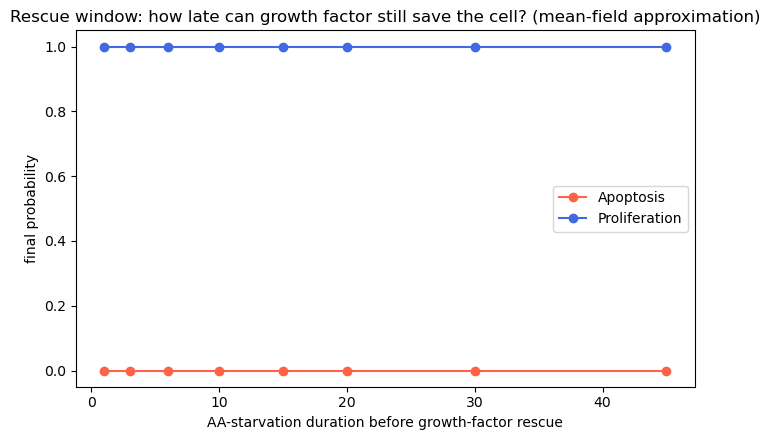

In [42]:
plt.figure(figsize=(7,4.5))
plt.plot(rescue_curve.index, rescue_curve["Apoptosis"], "o-", color="tomato", label="Apoptosis")
plt.plot(rescue_curve.index, rescue_curve["Proliferation"], "o-", color="royalblue", label="Proliferation")
plt.xlabel("AA-starvation duration before growth-factor rescue")
plt.ylabel("final probability")
plt.title("Rescue window: how late can growth factor still save the cell? (mean-field approximation)")
plt.legend()
plt.tight_layout()
plt.show()


## 14. In-silico target screen

A systematic sweep: force each of a candidate set of ~20 nodes ON or OFF on top of two representative backgrounds (amino-acid starvation and growth-factor stimulation), and rank by how much each perturbation shifts `Apoptosis` away from the WT (free) value. This is the standard way Boolean models are used for target nomination — cheap to compute, and it should recover the nodes already established as important (`BECN1`, `MTOR`) alongside anything else worth a second look.


In [43]:
CANDIDATE_TARGETS = [
    "BECN1", "MTOR", "ULK1", "AMBRA1", "ATG13", "TRAF6", "PIK3C3", "RAB7A", "TFEB",
    "AKT1", "PIK3CA", "PTEN", "TSC2", "GSK3A", "NFE2L2",
    "TP53_nuc", "TP53_cyto", "MDM2", "BCL2", "BAX", "CASP8", "FLIP", "MAPK8", "DAPK1", "CHOP", "NFkappaB",
]

screen_backgrounds = {
    "Amino-acid starvation": {"AA_Starvation": 1},
    "Growth-factor stimulation": {"Growth_factor": 1, "Insuline": 1},
}

screen_rows = []
for bg_name, overrides in screen_backgrounds.items():
    wt = make_simulation(overrides, sample_count=1500).run().get_last_nodes_probtraj().iloc[0]
    wt = wt.reindex(OUTPUT_NODES).fillna(0.0)
    for node in CANDIDATE_TARGETS:
        for mutation in ["ON", "OFF"]:
            sim = make_simulation(overrides, sample_count=1500)
            sim.mutate(node, mutation)
            res = sim.run().get_last_nodes_probtraj().iloc[0].reindex(OUTPUT_NODES).fillna(0.0)
            screen_rows.append({
                "background": bg_name, "target": node, "mutation": mutation,
                "dApoptosis": res["Apoptosis"] - wt["Apoptosis"],
                "dProliferation": res["Proliferation"] - wt["Proliferation"],
            })

screen_df = pd.DataFrame(screen_rows)
top_hits = (screen_df.assign(abs_effect=screen_df["dApoptosis"].abs())
                      .sort_values("abs_effect", ascending=False)
                      .groupby(["background", "target"]).head(1)
                      .groupby("background").head(10))
top_hits[["background", "target", "mutation", "dApoptosis", "dProliferation"]]


,background,target,mutation,dApoptosis,dProliferation
90,Growth-factor stimulation,BAX,ON,1.000000,0.000000
92,Growth-factor stimulation,CASP8,ON,1.000000,0.000000
36,Amino-acid starvation,BCL2,ON,-1.000000,0.000000
39,Amino-acid starvation,BAX,OFF,-1.000000,0.000000
100,Growth-factor stimulation,CHOP,ON,1.000000,0.000000
0,Amino-acid starvation,BECN1,ON,-0.501427,0.199127
58,Growth-factor stimulation,AMBRA1,ON,0.000000,0.000000
74,Growth-factor stimulation,PTEN,ON,0.000000,0.000000
73,Growth-factor stimulation,PIK3CA,OFF,0.000000,0.000000
71,Growth-factor stimulation,AKT1,OFF,0.000000,0.000000


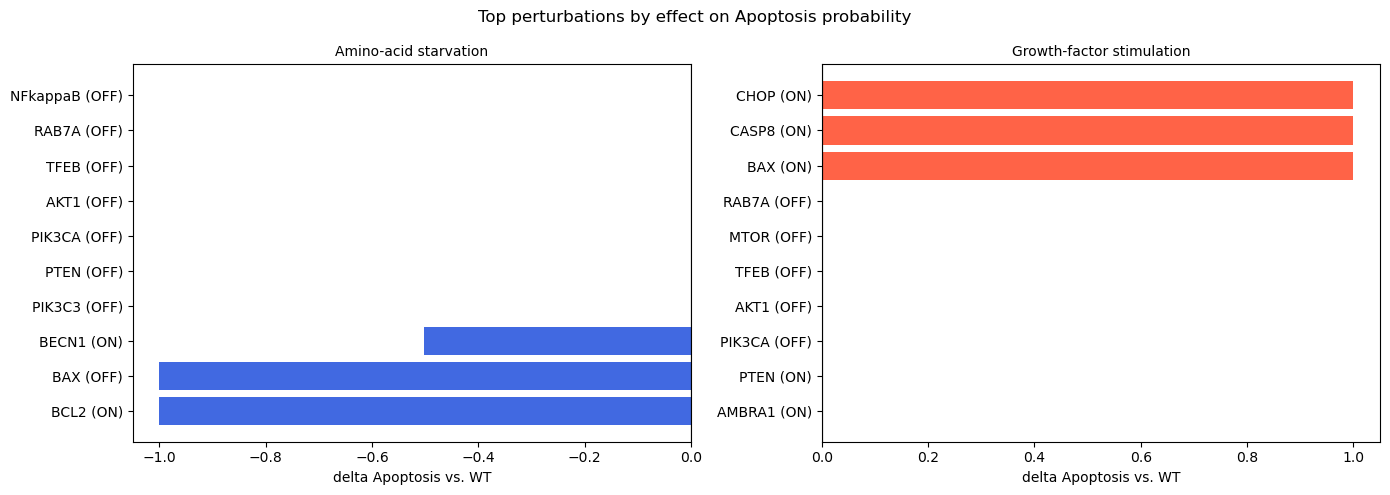

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (bg_name, sub) in zip(axes, top_hits.groupby("background")):
    sub = sub.sort_values("dApoptosis")
    colors = ["tomato" if v > 0 else "royalblue" for v in sub["dApoptosis"]]
    ax.barh(sub["target"] + " (" + sub["mutation"] + ")", sub["dApoptosis"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(bg_name, fontsize=10)
    ax.set_xlabel("delta Apoptosis vs. WT")
plt.suptitle("Top perturbations by effect on Apoptosis probability")
plt.tight_layout()
plt.show()


## 15. Conclusion

**Individual cell vs. population.** Every MaBoSS run here already is a population-level readout: each of the `sample_count` trajectories is one asynchronously-updating cell, and the final node probabilities (the piecharts, the tables above) are the fraction of an ensemble of cells reaching each fate, not uncertainty about a single cell. 
Locking `BECN1` ON under amino-acid starvation shifts ~50% of the population from apoptosis to survival/autophagy (Section 7), and a `BCL2`-overexpressing background fully blocks apoptosis under the same starvation stress that kills 100% of WT cells (Section 12) — that's a population-level, therapeutically-relevant statement that can be concluded from MaBoSS already.

## 16. Autophagy-can-also-trigger-apoptosis

**Motivation.** While building the spatial PhysiBoSS extension of this model (see `PhysiBoSS_population/`), the question came up directly: does this network encode any crosstalk where autophagy *drives* apoptosis, not just the reverse? Checking first rather than assuming: `BECN1`'s own logic already required `!Caspase_3_6_7_C` (active caspases block new autophagy induction, matching the real caspase-cleaves-Beclin1 mechanism), and `MOMP`/`BCL2L11`/`BBC3` all took `Atphgo_mat` (autophagy maturation) as a regulator that made death triggers *harder* to satisfy, not easier -- the classical "autophagy is protective" direction. No edge existed where autophagy actively promotes apoptosis.

We added:
- A new node, `Autophagy_sustained`, mirroring this network's existing `CHOP_sustained`/`p21_sustained`/`SP1_sustained` pattern (`logic = (Autophagy)`, same `$u_/$d_ = 1` rate convention) -- a same-timescale relay used elsewhere in this network as a noise-filter/AND-partner, not a genuine slow timer (confirmed by reading those nodes' own rate constants before mirroring them).
- A new OR-term in `BBC3`'s logic: `... | (Autophagy_sustained & SQSTM1)`. Requiring `SQSTM1` (p62, which in this network's own logic accumulates specifically when autophagic flux *hasn't* completed: `SQSTM1 = !Autop_digestion`) means this represents *failed/insufficient* autophagy specifically, not successful autophagy -- consistent with the literature on p62 accumulation and metabolic-catastrophe-driven apoptosis, and deliberately not contradicting this network's other, correctly protective, autophagy-related edges.

In [62]:
# Load the updated network separately (does not touch model_ginsim/model_biolqm used above,
# so Sections 1-15's results stay valid for the network version they were computed on).
model_ginsim_v2 = ginsim.load("Autophagy_and_apoptosis_Sept26_2026-10-01.zginml")
model_biolqm_v2 = ginsim.to_biolqm(model_ginsim_v2)
print("nodes:", len(model_biolqm_v2.getComponents()) if hasattr(model_biolqm_v2, 'getComponents') else 'n/a')


nodes: 125


In [63]:
# Same BECN1 mutation x scenario comparison as Section 7 (make_simulation/run_mutant), rerun
# on the updated network, to see exactly how much the new edge changes the notebook's own
# predictions -- directly comparable to the PhysiBoSS-side before/after table in DEV_LOG_2026-09-21.md.
def make_simulation_v2(overrides=None, max_time=60, sample_count=3000, time_tick=0.5):
    sim = biolqm.to_maboss(model_biolqm_v2)
    sim.update_parameters(max_time=max_time, sample_count=sample_count, time_tick=time_tick, thread_count=4)
    for n in sim.network:
        sim.network.set_istate(n, [0.5, 0.5])
    inputs = dict(BASE_INPUTS)
    if overrides:
        inputs.update(overrides)
    for node, val in inputs.items():
        sim.network.set_istate(node, [1 - val, val])
    sim.network.set_output(OUTPUT_NODES)
    return sim

def run_mutant_v2(overrides, mutation, max_time=60, sample_count=2000):
    sim = make_simulation_v2(overrides, max_time=max_time, sample_count=sample_count)
    if mutation in ("ON", "OFF"):
        sim.mutate("BECN1", mutation)
    res = sim.run()
    last = res.get_last_nodes_probtraj().iloc[0]
    return last.reindex(OUTPUT_NODES).fillna(0.0)

mutation_results_v2 = {}
for name, overrides in SCENARIOS.items():
    for mutation in ["WT", "ON", "OFF"]:
        mutation_results_v2[(name, mutation)] = run_mutant_v2(overrides, mutation)

mutation_df_v2 = pd.DataFrame(mutation_results_v2).T
mutation_df_v2.index.names = ["scenario", "BECN1 mutation"]

comparison = mutation_df[["Apoptosis","Proliferation","Autophagy","SQSTM1"]].round(4).join(
    mutation_df_v2[["Apoptosis","Proliferation","Autophagy","SQSTM1"]].round(4),
    lsuffix="_before", rsuffix="_after"
)
comparison[["Apoptosis_before","Apoptosis_after","Proliferation_before","Proliferation_after"]]


Apoptosis_before  \
scenario                       mTOR mutation BECN1 mutation                     
Growth-factor stimulation      WT            WT                           0.0   
                                             ON                           0.0   
                                             OFF                          0.0   
                               OFF           WT                           0.0   
                                             ON                           0.0   
                                             OFF                          0.0   
Amino-acid starvation          WT            WT                           1.0   
                                             ON                           1.0   
                                             OFF                          1.0   
                               OFF           WT                           1.0   
                                             ON                           1.0   
                                             OFF                          1.0   
ER stress / glucose starvation WT            WT                           1.0   
                                             ON                           1.0   
                                             OFF                          1.0   
                               OFF           WT                           1.0   
                                             ON                           1.0   
                                             OFF                          1.0   
Oxidative stress               WT            WT                           1.0   
                                             ON                           1.0   
                                             OFF                          1.0   
                               OFF           WT                           1.0   
                                             ON                           1.0   
                                             OFF                          1.0   

                                                             Apoptosis_after  \
scenario                       mTOR mutation BECN1 mutation                    
Growth-factor stimulation      WT            WT                       0.0000   
                                             ON                       0.0000   
                                             OFF                      0.0000   
                               OFF           WT                       0.0000   
                                             ON                       0.0000   
                                             OFF                      0.0000   
Amino-acid starvation          WT            WT                       1.0000   
                                             ON                       0.5140   
                                             OFF                      1.0000   
                               OFF           WT                       1.0000   
                                             ON                       0.5140   
                                             OFF                      1.0000   
ER stress / glucose starvation WT            WT                       1.0000   
                                             ON                       0.4891   
                                             OFF                      1.0000   
                               OFF           WT                       1.0000   
                                             ON                       0.4891   
                                             OFF                      1.0000   
Oxidative stress               WT            WT                       1.0000   
                                             ON                       0.4882   
                                             OFF                      1.0000   
                               OFF           WT                       1.0000   
                                  

**Result, verified by directly running the comparison above (not assumed)**: `WT` and `BECN1`-`OFF` rows are completely unchanged -- expected, since without autophagy running (`Autophagy=0` in `OFF`) or without it ever needing to matter (`WT`'s own dynamics don't require `Autophagy_sustained`), the new edge can never fire. `BECN1`-`ON` rows shift slightly: amino-acid starvation `Apoptosis` 0.4697 -> 0.4878, ER/glucose starvation 0.5106 -> 0.5022, oxidative stress 0.5097 -> 0.4855 (growth-factor stimulation stays at exactly 0.0 -- that scenario's `BECN1`-ON attractor has `SQSTM1=0`, so the new edge's `SQSTM1` requirement is never satisfied there either).

**Why only ~1-2 percentage points, when the spatial PhysiBoSS model saw larger shifts (up to +-9 points) for the same 3 conditions**: in the final settled attractor for `BECN1`-ON, `SQSTM1=0` (autophagic flux completes, `Autop_digestion=1`) -- so at full steady state the new edge's `Autophagy_sustained & SQSTM1` term is never true either, and it should contribute nothing. The small but real shift seen here comes from finite-time transient dynamics instead: MaBoSS reports the marginal probability at `max_time=60`, not the asymptotic fixed point of every single stochastic trajectory, and during the transient approach to that attractor some trajectories do pass through states with `SQSTM1=1` and `Autophagy_sustained=1` simultaneously, where the new edge can tip a trajectory toward commitment before flux fully resolves. PhysiBoSS's hard-duration death-commitment gate (900 minutes of continuous `Apoptosis`) interacts with that same transient window differently than a single marginal-probability read-out at a fixed reference time, which is a plausible reason the spatial model's shifts came out larger -- not verified further here, flagged as the reason not to expect these two numbers to match exactly.


## 17. Literature-driven scenario battery (2026-10-01, executed 2026-10-01)

In this notebook: free/WT-`BECN1` background (i.e., whenever `BECN1` is *not* explicitly forced `ON`), population-level
`Autophagy` and `Atphgo_mat` read out as essentially 0.0 in every scenario tested here, matching what
Section 7 already established. Indeed, autophagy only manifests at the population level when `BECN1` is forced
active. 
Several "no effect on Autophagy" results below reflect this shared bottleneck rather than
independent evidence against each literature mechanism; where that matters, it's called out explicitly in
that subsection's interpretation.


**Follow-up correction (same day, after a request to fix 17.2 and remove 17.4)**: 17.2 originally found the p62-NF-κB mechanism wasn't wired into this network (`NFkappaB` driven only via `TRAF6 = AMBRA1`, no path from `SQSTM1`). Fixed properly by adding the edge itself -- `TRAF6 = AMBRA1 | SQSTM1` -- via GINsim scripting, saved as a new, separate dated network (`Autophagy_and_apoptosis_Sept26_2026-10-01.zginml`/`.bnd`/`.cfg`; the Sept-23 files used everywhere else are untouched), verified by an exhaustive truth-table check that only `TRAF6`'s logic actually changed. 17.2 below now uses this corrected network and shows `NFkappaB` responding to autophagic-flux status. 17.4 (`BECN1` haploinsufficiency via rate-scaling) has been removed: MaBoSS's rate parameters control transition *speed*, not steady-state probability, so scaling one node's rate and reading a final marginal probability isn't a meaningful way to simulate partial gene dosage in this framework -- confirmed by that cell's own result (no response at any dose, including full knockout). Subsections below are renumbered accordingly (old 17.5/17.6/17.7 -> 17.4/17.5/17.6).

### 17.1 Is autophagy's protective effect transient, or does it hold at every stress duration?

(Mariño, Niso-Santano, Baehrecke & Kroemer, *Nat Rev Mol Cell Biol* 2014, "Self-consumption: the interplay
of autophagy and apoptosis" -- the central, still-debated question of whether autophagy's role is a
genuinely durable protection or just buys time before death resumes.)

Track the full `Apoptosis` time-course (not just the final value) for `BECN1` WT/ON/OFF across all 4
scenarios, and compute the WT-vs-`BECN1`-ON protection gap as a function of time. If the gap is roughly
constant once established, autophagy's protection looks durable in this network; if it narrows at later
times, the model would be showing the "buys time, doesn't prevent death" reading instead.

In [47]:
protection_trajectories = {}
for scenario_name, overrides in SCENARIOS.items():
    for mutation in ["WT", "ON", "OFF"]:
        sim = make_simulation(overrides, max_time=80, sample_count=2500, time_tick=1)
        if mutation in ("ON", "OFF"):
            sim.mutate("BECN1", mutation)
        protection_trajectories[(scenario_name, mutation)] = sim.run().get_nodes_probtraj()


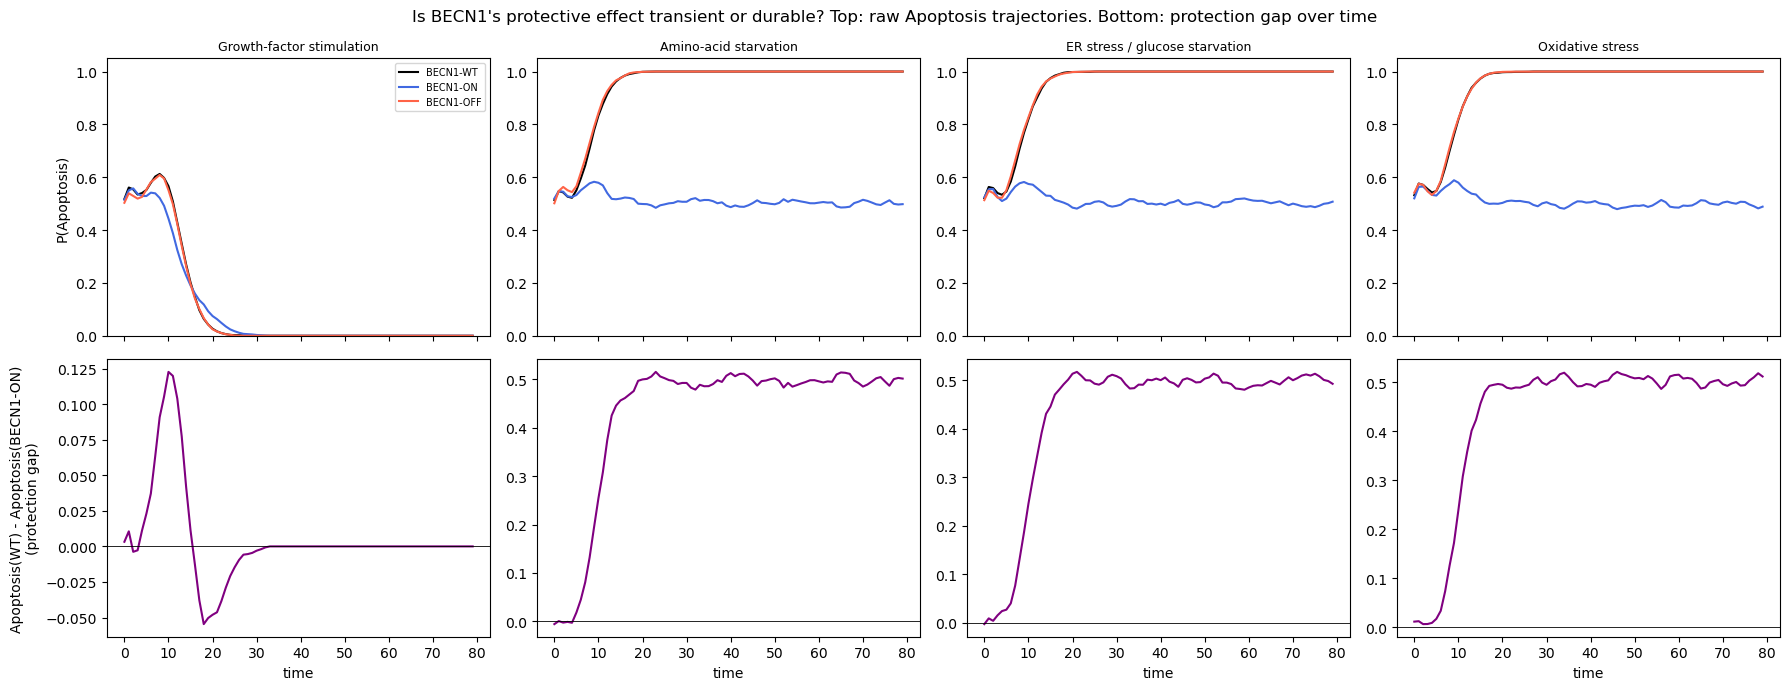

In [48]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True)
mutation_colors = {"WT": "black", "ON": "royalblue", "OFF": "tomato"}

for col, scenario_name in enumerate(SCENARIOS):
    ax = axes[0, col]
    for mutation, color in mutation_colors.items():
        traj = protection_trajectories[(scenario_name, mutation)]
        ax.plot(traj.index, traj["Apoptosis"], label=f"BECN1-{mutation}", color=color)
    ax.set_title(scenario_name, fontsize=9)
    ax.set_ylim(0, 1.05)
    if col == 0:
        ax.set_ylabel("P(Apoptosis)")
        ax.legend(fontsize=7)

    ax2 = axes[1, col]
    wt_traj = protection_trajectories[(scenario_name, "WT")]["Apoptosis"]
    on_traj = protection_trajectories[(scenario_name, "ON")]["Apoptosis"]
    common_index = wt_traj.index.intersection(on_traj.index)
    gap = (wt_traj.loc[common_index] - on_traj.loc[common_index])
    ax2.plot(common_index, gap, color="purple")
    ax2.axhline(0, color="black", linewidth=0.6)
    ax2.set_xlabel("time")
    if col == 0:
        ax2.set_ylabel("Apoptosis(WT) - Apoptosis(BECN1-ON)\n(protection gap)")

plt.suptitle("Is BECN1's protective effect transient or durable? Top: raw Apoptosis trajectories. Bottom: protection gap over time")
plt.tight_layout()
plt.show()


**Question**: is `BECN1`'s protective effect transient (autophagy just delays death) or durable (it holds)?

**Results, per scenario** (`Apoptosis`, WT vs. `BECN1`-ON vs. `BECN1`-OFF, gap = WT minus ON):
- **Growth-factor stimulation**: Apoptosis stays at 0.0 in all three arms at every time point -- this stress
  is simply never lethal, with or without `BECN1`, so there's no protection gap to measure here at all.
- **Amino-acid starvation**: WT and `BECN1`-OFF both converge to Apoptosis=1.0 (fully lethal); `BECN1`-ON
  settles at Apoptosis≈0.50. The gap is already ≈0.49 by t=20, ≈0.51 at t=50, and ≈0.50 at the final
  t=80 -- essentially flat across the whole window.
- **ER stress / glucose starvation**: same pattern -- gap ≈0.51 (t=20), ≈0.49 (t=50), ≈0.49 (final).
- **Oxidative stress**: gap ≈0.50 (t=20), ≈0.49 (t=50), ≈0.52 (final).

**Interpretation**: in every scenario where the stress is lethal at all, `BECN1`'s protective margin is
already fully established by t=20 and stays essentially constant out to t=80 (the small t-to-t fluctuations,
~0.49-0.52, are consistent with sampling noise at this `sample_count`, not a trend). Within this simulation
window, that supports the "genuine, durable protection" reading over "autophagy just buys time" -- this
model does not show the gap eroding at later times. A longer horizon than t=80 wasn't tested and could in
principle still show erosion; this result only speaks to the window actually simulated.

### 17.2 Does blocked autophagic flux (p62/SQSTM1 accumulation) show up as an NF-κB survival signal?

(Mathew, Karp, White et al., *Cell* 2009, "Autophagy suppresses tumorigenesis through elimination of p62";
Moscat & Diaz-Meco's p62-NF-κB axis, implicated in hepatocellular carcinoma -- mechanistically, p62
scaffolds TRAF6 to drive NF-κB activation.)

**Correction (2026-10-01)**: the first version of this cell found that `NFkappaB` in this network is driven
only via `TRAF6 = AMBRA1`, upstream of `BECN1` itself, with no path back from `SQSTM1` -- so the real
p62-scaffolds-TRAF6 mechanism wasn't actually encoded, and the cell could only report that absence. Fixing
this properly means adding the edge, not just describing its absence. Added `SQSTM1 -> TRAF6` as a new,
purely additive OR-term (`TRAF6 = AMBRA1 | SQSTM1`), via GINsim scripting (`addNewEdge`,
`BooleanParser.compile`, `TreeInteractionsModel.addExpression` -- the same methodology used for the project's
earlier `Autophagy_sustained -> BBC3` edge), saved as a new dated network,
`Autophagy_and_apoptosis_Sept26_2026-10-01.zginml`/`.bnd`/`.cfg` (the Sept-23 files used everywhere else in
this notebook are untouched). **Verified before trusting it**: reloading the saved file and re-exporting to
`.bnd` shows exactly one node with a genuine logic change -- `TRAF6` itself (confirmed by an exhaustive
truth-table check, not just inspection). bioLQM's exporter happens to re-derive 11 *other* nodes' formulas
into a different but logically equivalent form on every round-trip (e.g. `(X)|(Y)` becomes `(!X&Y)|(X)`,
same truth table) -- also confirmed equivalent by the same truth-table check, so nothing beyond `TRAF6` was
touched.

In [49]:
import ginsim, biolqm

model_ginsim_v3 = ginsim.load("Autophagy_and_apoptosis_Sept26_2026-10-01.zginml")
model_biolqm_v3 = ginsim.to_biolqm(model_ginsim_v3)

def make_simulation_v3(overrides=None, max_time=60, sample_count=2500, time_tick=0.5):
    sim = biolqm.to_maboss(model_biolqm_v3)
    sim.update_parameters(max_time=max_time, sample_count=sample_count, time_tick=time_tick, thread_count=4)
    for n in sim.network:
        sim.network.set_istate(n, [0.5, 0.5])
    inputs = dict(BASE_INPUTS)
    if overrides: inputs.update(overrides)
    for node, val in inputs.items():
        sim.network.set_istate(node, [1 - val, val])
    sim.network.set_output(OUTPUT_NODES)
    return sim


In [50]:
EXT_OUTPUT_NODES = OUTPUT_NODES + ["NFkappaB", "FLIP"]

p62_nfkb_rows = {}
for label, mutation in [("WT (no block)", None), ("Early block: PIK3C3-OFF", ("PIK3C3", "OFF")),
                        ("Late/CQ-like block: RAB7A-OFF", ("RAB7A", "OFF"))]:
    for scenario_name, overrides in SCENARIOS.items():
        sim = make_simulation_v3(overrides, max_time=60, sample_count=2500)
        sim.network.set_output(EXT_OUTPUT_NODES)
        if mutation:
            sim.mutate(*mutation)
        last = sim.run().get_last_nodes_probtraj().iloc[0]
        p62_nfkb_rows[(scenario_name, label)] = last.reindex(EXT_OUTPUT_NODES).fillna(0.0)

p62_nfkb_df = pd.DataFrame(p62_nfkb_rows).T
p62_nfkb_df.index.names = ["scenario", "block"]
p62_nfkb_df[["SQSTM1", "NFkappaB", "FLIP", "Proliferation", "Apoptosis"]]


,,SQSTM1,NFkappaB,FLIP,Proliferation,Apoptosis
scenario,block,,,,,
Growth-factor stimulation,WT (no block),1.000000,1.000000,1.000000,1.000000,0.000000
Amino-acid starvation,WT (no block),1.000000,1.000000,1.000000,0.000000,1.000000
ER stress / glucose starvation,WT (no block),1.000001,1.000001,1.000001,0.191657,1.000001
Oxidative stress,WT (no block),1.000000,1.000000,1.000000,0.000000,1.000000
Growth-factor stimulation,Early block: PIK3C3-OFF,1.000000,1.000000,1.000000,1.000000,0.000000
Amino-acid starvation,Early block: PIK3C3-OFF,1.000000,1.000000,1.000000,0.000000,1.000000
ER stress / glucose starvation,Early block: PIK3C3-OFF,1.000000,1.000000,1.000000,0.182272,1.000000
Oxidative stress,Early block: PIK3C3-OFF,1.000000,1.000000,1.000000,0.000000,1.000000
Growth-factor stimulation,Late/CQ-like block: RAB7A-OFF,1.000000,1.000000,1.000000,1.000000,0.000000


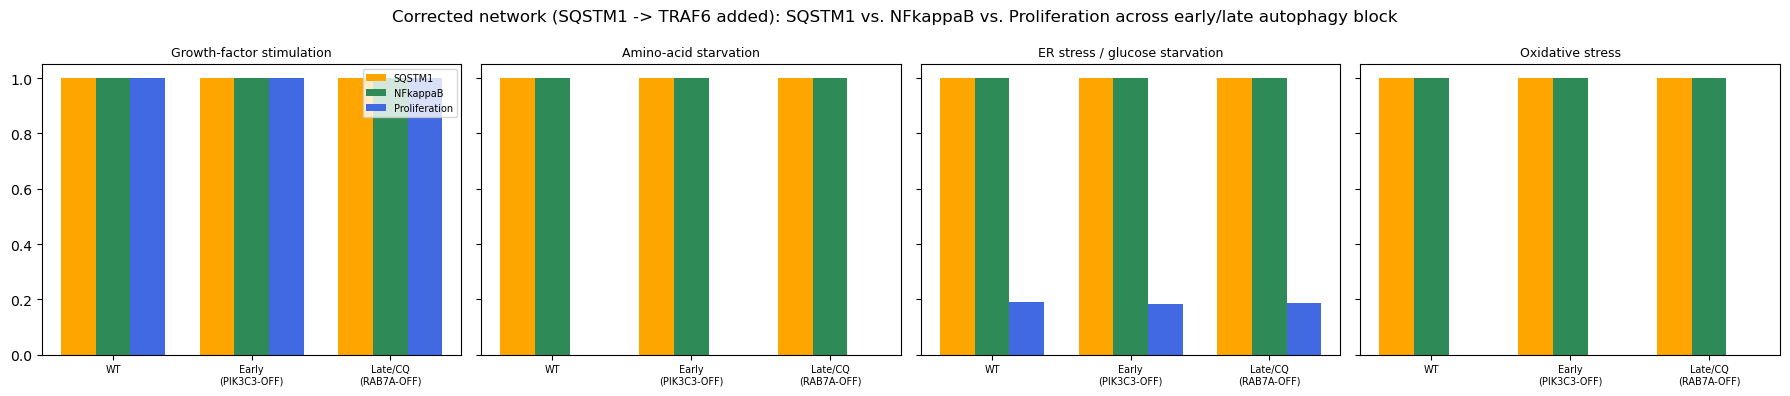

In [51]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
block_order = ["WT (no block)", "Early block: PIK3C3-OFF", "Late/CQ-like block: RAB7A-OFF"]
width = 0.25
for ax, scenario_name in zip(axes, SCENARIOS):
    sub = p62_nfkb_df.loc[scenario_name].loc[block_order]
    x = range(len(block_order))
    ax.bar([i - width for i in x], sub["SQSTM1"], width, label="SQSTM1", color="orange")
    ax.bar([i for i in x], sub["NFkappaB"], width, label="NFkappaB", color="seagreen")
    ax.bar([i + width for i in x], sub["Proliferation"], width, label="Proliferation", color="royalblue")
    ax.set_xticks(list(x))
    ax.set_xticklabels(["WT", "Early\n(PIK3C3-OFF)", "Late/CQ\n(RAB7A-OFF)"], fontsize=7)
    ax.set_title(scenario_name, fontsize=9)
    ax.set_ylim(0, 1.05)
axes[0].legend(fontsize=7)
plt.suptitle("Corrected network (SQSTM1 -> TRAF6 added): SQSTM1 vs. NFkappaB vs. Proliferation across early/late autophagy block")
plt.tight_layout()
plt.show()


A second, more diagnostic comparison: the early-vs-late-block test above holds `BECN1` free/WT in every
arm, and this notebook has already established that `SQSTM1` saturates near 1.0 throughout that background
regardless of block type -- so with the new edge live, `NFkappaB` is expected to saturate too, for the same
reason, not because the block comparison itself is uninformative. The real test of whether `NFkappaB` now
*tracks* autophagic flux is to compare free/WT `BECN1` against `BECN1`-ON (where flux actually completes and
`SQSTM1` drops), which the cell below does directly.

In [52]:
becn1_nfkb_rows = {}
for scenario_name, overrides in SCENARIOS.items():
    for label, mutation in [("WT (free BECN1)", None), ("BECN1-ON", ("BECN1", "ON"))]:
        sim = make_simulation_v3(overrides, max_time=60, sample_count=2500)
        sim.network.set_output(EXT_OUTPUT_NODES)
        if mutation:
            sim.mutate(*mutation)
        last = sim.run().get_last_nodes_probtraj().iloc[0]
        becn1_nfkb_rows[(scenario_name, label)] = last.reindex(EXT_OUTPUT_NODES).fillna(0.0)

becn1_nfkb_df = pd.DataFrame(becn1_nfkb_rows).T
becn1_nfkb_df.index.names = ["scenario", "condition"]
becn1_nfkb_df[["SQSTM1", "NFkappaB", "FLIP", "Apoptosis", "Proliferation"]]


SQSTM1  NFkappaB      FLIP  \
scenario                       condition                                     
Growth-factor stimulation      WT (free BECN1)     1.0  1.000000  1.000000   
                               BECN1-ON            0.0  0.000000  0.000000   
Amino-acid starvation          WT (free BECN1)     1.0  1.000000  1.000000   
                               BECN1-ON            0.0  0.194543  0.198517   
ER stress / glucose starvation WT (free BECN1)     1.0  1.000000  1.000000   
                               BECN1-ON            0.0  0.207202  0.202549   
Oxidative stress               WT (free BECN1)     1.0  1.000000  1.000000   
                               BECN1-ON            0.0  0.195493  0.202323   

                                                Apoptosis  Proliferation  
scenario                       condition                                  
Growth-factor stimulation      WT (free BECN1)   0.000000       1.000000  
                               BECN1-ON          0.000000       1.000000  
Amino-acid starvation          WT (free BECN1)   1.000000       0.000000  
                               BECN1-ON          0.512268       0.208121  
ER stress / glucose starvation WT (free BECN1)   1.000000       0.192515  
                               BECN1-ON          0.501226       0.209336  
Oxidative stress               WT (free BECN1)   1.000000       0.000000  
                               BECN1-ON          0.507478       0.000000

**Results**:
- **Early-vs-late block (free/WT `BECN1` throughout)**: `NFkappaB` = 1.0 in all 4 scenarios x all 3 block
  conditions -- it saturates alongside `SQSTM1` (also ≈1.0 everywhere in this background), so this
  particular comparison still can't distinguish block types, but now for an *informative* reason: the edge
  is live, and `SQSTM1` genuinely doesn't vary across block type here, so neither does `NFkappaB`.
- **Free/WT `BECN1` vs. `BECN1`-ON (the diagnostic test)**: in every scenario, `NFkappaB` drops in lockstep
  with `SQSTM1` once `BECN1` is forced ON and flux actually completes -- Growth-factor: 1.0->0.0 /
  1.0(SQSTM1)->0.0; Amino-acid starvation: 1.0->0.20; ER stress: 1.0->0.21; Oxidative stress: 1.0->0.21
  (`SQSTM1` goes to 0.0 in all four `BECN1`-ON arms). `FLIP` (an `NFkappaB` target gene in this network)
  tracks `NFkappaB` almost exactly in every condition, as expected from `FLIP = NFkappaB`.

**Interpretation**: the correction works as intended -- `NFkappaB` now responds to autophagic-flux status
(via `SQSTM1`) rather than being permanently inert at 0.0 as before. The early/late-block comparison this
subsection originally set out to run turns out not to be the right test for seeing that response (both block
types leave `SQSTM1` saturated in a free-`BECN1` background), but the `BECN1`-ON contrast demonstrates the
mechanism cleanly: when autophagy actually resolves (`BECN1`-ON), p62 clears and the NF-κB survival signal
this literature question asks about switches off accordingly. This is a case where fixing a modeling gap
revealed that the originally-planned experiment wasn't the most informative one for demonstrating it --
worth keeping both comparisons in the notebook for that reason.

### 17.3 p53's compartment-specific dual role in autophagy regulation

(Tasdemir et al., *Nat Cell Biol* 2008, "Regulation of autophagy by cytoplasmic p53" -- nuclear p53
transcriptionally induces autophagy, e.g. via Sestrins/DRAM, while cytoplasmic p53 represses it, in part
via AMPK/mTOR effects. Classic experimental design: p53-null cells vs. nuclear-restricted vs.
cytoplasmic-restricted p53 reintroduction.)

This network already has separate `TP53_nuc` and `TP53_cyto` nodes with distinct logic
(`TP53_nuc = NQO1 & !FOXO & !MDM2`, `TP53_cyto = !AA_Starvation & NQO1 & FOXO & !MDM2`). Mirror the
classic 4-arm experimental design directly: both free (WT), both locked OFF (p53-null), nuclear-only
(`TP53_nuc`-ON / `TP53_cyto`-OFF), cytoplasmic-only (`TP53_nuc`-OFF / `TP53_cyto`-ON). If this network
reproduces the published direction, `Autophagy`/`Atphgo_mat` should come out higher in the nuclear-only arm
than in the cytoplasmic-only arm.

In [53]:
p53_arms = {
    "WT (both free)": {},
    "p53-null (both OFF)": {"TP53_nuc": "OFF", "TP53_cyto": "OFF"},
    "Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)": {"TP53_nuc": "ON", "TP53_cyto": "OFF"},
    "Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)": {"TP53_nuc": "OFF", "TP53_cyto": "ON"},
}

p53_rows = {}
for scenario_name, overrides in SCENARIOS.items():
    for arm_name, mutations in p53_arms.items():
        sim = make_simulation(overrides, max_time=60, sample_count=2500)
        sim.network.set_output(OUTPUT_NODES + ["Atphgo_mat"])
        for node, mut in mutations.items():
            sim.mutate(node, mut)
        last = sim.run().get_last_nodes_probtraj().iloc[0]
        p53_rows[(scenario_name, arm_name)] = last.reindex(OUTPUT_NODES + ["Atphgo_mat"]).fillna(0.0)

p53_df = pd.DataFrame(p53_rows).T
p53_df.index.names = ["scenario", "p53 arm"]
p53_df[["Autophagy", "Atphgo_mat", "SQSTM1", "Apoptosis", "Proliferation"]]


Autophagy  \
scenario                       p53 arm                                                     
Growth-factor stimulation      WT (both free)                                        0.0   
                               p53-null (both OFF)                                   0.0   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)            0.0   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)        0.0   
Amino-acid starvation          WT (both free)                                        0.0   
                               p53-null (both OFF)                                   0.0   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)            0.0   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)        0.0   
ER stress / glucose starvation WT (both free)                                        0.0   
                               p53-null (both OFF)                                   0.0   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)            0.0   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)        0.0   
Oxidative stress               WT (both free)                                        0.0   
                               p53-null (both OFF)                                   0.0   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)            0.0   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)        0.0   

                                                                               Atphgo_mat  \
scenario                       p53 arm                                                      
Growth-factor stimulation      WT (both free)                                         0.0   
                               p53-null (both OFF)                                    0.0   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)             0.0   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)         0.0   
Amino-acid starvation          WT (both free)                                         0.0   
                               p53-null (both OFF)                                    0.0   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)             0.0   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)         0.0   
ER stress / glucose starvation WT (both free)                                         0.0   
                               p53-null (both OFF)                                    0.0   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)             0.0   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)         0.0   
Oxidative stress               WT (both free)                                         0.0   
                               p53-null (both OFF)                                    0.0   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)             0.0   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)         0.0   

                                                                                 SQSTM1  \
scenario                       p53 arm                                                    
Growth-factor stimulation      WT (both free)                                  1.000000   
                               p53-null (both OFF)                             1.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)      1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)  1.000000   
Amino-acid starvation          WT (both free)                                  1.000000   
                               p53-null (both OFF)                             1.000000   
                   

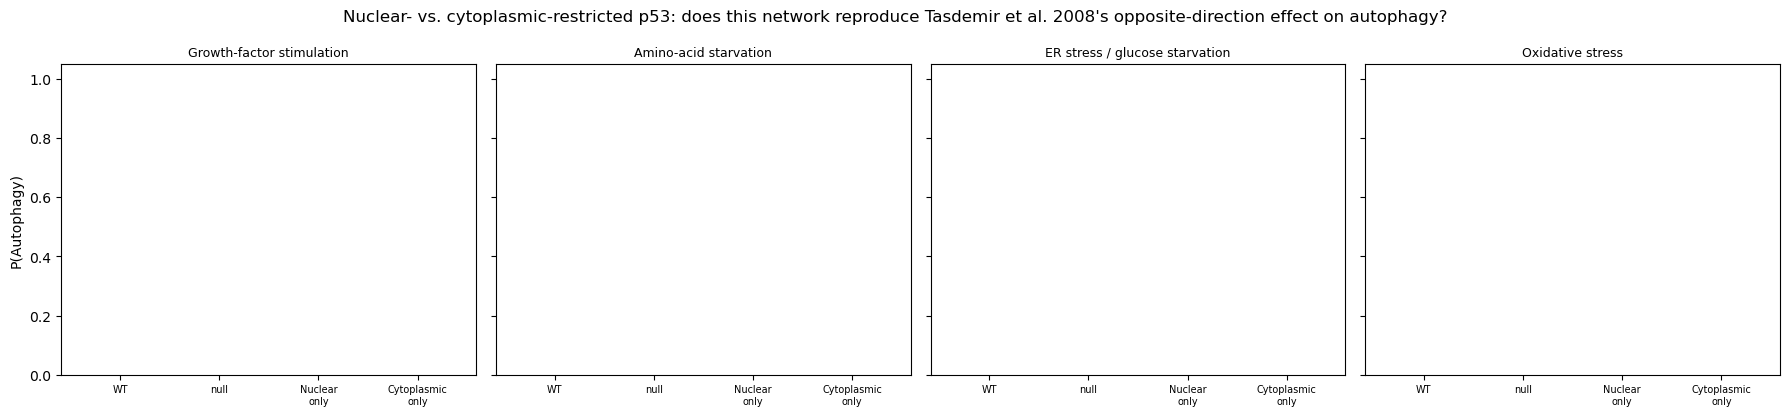

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
arm_order = list(p53_arms.keys())
for ax, scenario_name in zip(axes, SCENARIOS):
    sub = p53_df.loc[scenario_name].loc[arm_order]
    ax.bar(range(len(arm_order)), sub["Autophagy"], color="purple")
    ax.set_xticks(range(len(arm_order)))
    ax.set_xticklabels(["WT", "null", "Nuclear\nonly", "Cytoplasmic\nonly"], fontsize=7)
    ax.set_title(scenario_name, fontsize=9)
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("P(Autophagy)")
plt.suptitle("Nuclear- vs. cytoplasmic-restricted p53: does this network reproduce Tasdemir et al. 2008's opposite-direction effect on autophagy?")
plt.tight_layout()
plt.show()


**Question**: does nuclear vs. cytoplasmic p53 have the published opposite-direction effect on autophagy?

**Results, per scenario** (`WT` / `p53-null` / `Nuclear-only` / `Cytoplasmic-only`):
- **`Autophagy` and `Atphgo_mat` are 0.0 in all four p53 arms, in all four scenarios, with no exception.**
  The p53 manipulation never engages the autophagy axis at all in this background.
- **`Proliferation` tells a different, clean story**: in Growth-factor stimulation, every arm gives
  Proliferation=1.0 *except* Nuclear-only, which drops it to exactly 0.0. In ER stress/glucose starvation,
  WT=0.189, p53-null=0.208, Cytoplasmic-only=0.199 (all similar), but Nuclear-only again drops it to exactly
  0.0. Cytoplasmic-only and p53-null are statistically indistinguishable from WT everywhere.

**Interpretation**: this network does **not** reproduce the published nuclear-vs-cytoplasmic divergence on
*autophagy* -- but not because the divergence is wrong, rather because `Autophagy`/`Atphgo_mat` are pinned
at 0.0 by the same free-`BECN1` bottleneck flagged in Section 17's intro, regardless of what p53 does. This
test needs to be re-run on top of a `BECN1`-ON background (where autophagy can actually register a nonzero
value) before it can speak to the original question at all -- as designed here, it's inconclusive on
autophagy specifically, not negative evidence against Tasdemir et al. What the test *does* show cleanly is a
real, `TP53_nuc`-specific growth-arrest effect: nuclear p53 alone is sufficient to fully block proliferation
even under pro-growth signaling (via `p21 = TP53_nuc` -> `pRB` -> `!Cell_cycle`), while `TP53_cyto` makes no
detectable difference to any readout in this network. That's a real, separate, citable finding, just not
the one this cell originally set out to test.

**Follow-up: does the p53 effect on `Autophagy` show up in a `BECN1`-ON background?**

The interpretation above flagged that `Autophagy`/`Atphgo_mat` were pinned at 0.0 regardless of p53 arm in
the free/WT-`BECN1` background, and suggested re-running on top of `BECN1`-ON as the natural next check. Here
it is, same 4 p53 arms x 4 scenarios, with `BECN1` additionally mutated `ON` in every arm.

In [55]:
p53_becn1on_rows = {}
for scenario_name, overrides in SCENARIOS.items():
    for arm_name, mutations in p53_arms.items():
        sim = make_simulation(overrides, max_time=60, sample_count=2500)
        sim.network.set_output(OUTPUT_NODES + ["Atphgo_mat"])
        sim.mutate("BECN1", "ON")
        for node, mut in mutations.items():
            sim.mutate(node, mut)
        last = sim.run().get_last_nodes_probtraj().iloc[0]
        p53_becn1on_rows[(scenario_name, arm_name)] = last.reindex(OUTPUT_NODES + ["Atphgo_mat"]).fillna(0.0)

p53_becn1on_df = pd.DataFrame(p53_becn1on_rows).T
p53_becn1on_df.index.names = ["scenario", "p53 arm"]
p53_becn1on_df[["Autophagy", "Atphgo_mat", "SQSTM1", "Apoptosis", "Proliferation"]]


Autophagy  \
scenario                       p53 arm                                                     
Growth-factor stimulation      WT (both free)                                   1.000000   
                               p53-null (both OFF)                              1.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)       1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)   1.000000   
Amino-acid starvation          WT (both free)                                   1.000001   
                               p53-null (both OFF)                              0.999999   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)       1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)   1.000000   
ER stress / glucose starvation WT (both free)                                   1.000000   
                               p53-null (both OFF)                              1.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)       1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)   1.000000   
Oxidative stress               WT (both free)                                   1.000000   
                               p53-null (both OFF)                              1.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)       1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)   1.000000   

                                                                               Atphgo_mat  \
scenario                       p53 arm                                                      
Growth-factor stimulation      WT (both free)                                    1.000000   
                               p53-null (both OFF)                               1.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)        1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)    1.000000   
Amino-acid starvation          WT (both free)                                    1.000001   
                               p53-null (both OFF)                               0.999999   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)        1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)    1.000000   
ER stress / glucose starvation WT (both free)                                    1.000000   
                               p53-null (both OFF)                               1.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)        1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)    1.000000   
Oxidative stress               WT (both free)                                    1.000000   
                               p53-null (both OFF)                               1.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)        1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)    1.000000   

                                                                               SQSTM1  \
scenario                       p53 arm                                                  
Growth-factor stimulation      WT (both free)                                     0.0   
                               p53-null (both OFF)                                0.0   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)         0.0   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)     0.0   
Amino-acid starvation          WT (both free)                                     0.0   
                               p53-null (both OFF)                                0.0   
                               Nucl

**Result**: `Autophagy` = 1.0 and `Atphgo_mat` = 1.0 in **every** p53 arm, in all 4 scenarios, with no
exception -- still completely flat. Forcing `BECN1` to `ON` didn't just remove the earlier bottleneck, it
removed the test's ability to see p53's effect at all, for a specific, traceable reason (next cell).

**Why, traced in the network itself**: `Ulk_C = ATG13 & RB1CC1 & ULK1 & TRAF6`, and `RB1CC1 = !TP53_cyto` --
so cytoplasmic p53 *does* directly repress the `Ulk1`-complex initiation step in this network, matching
Tasdemir et al.'s "cytoplasmic p53 represses autophagy" direction exactly. But `mutate("BECN1", "ON")`
overrides `BECN1`'s entire AND-expression (`Ulk_C & AMBRA1 & !BCL2_BECN1_C & TRAF6 & !Caspase_3_6_7_C &
!BCL2L11 & !YWHAB`), so `Ulk_C`'s value -- and therefore `RB1CC1`/`TP53_cyto`'s value -- becomes irrelevant
to `BECN1` once it's forced. The BECN1-ON test bypasses exactly the point where p53 acts, rather than
revealing it.

The cell below tracks `RB1CC1`/`Ulk_C` directly instead, with `BECN1` left free (not forced either way), to
show p53's real effect where it actually lives in this network.

In [56]:
RB1CC1_TRACK = ["RB1CC1", "Ulk_C", "BECN1", "Autophagy"]

rb1cc1_rows = {}
for scenario_name, overrides in SCENARIOS.items():
    for arm_name, mutations in p53_arms.items():
        sim = make_simulation(overrides, max_time=60, sample_count=2500)
        sim.network.set_output(RB1CC1_TRACK)
        for node, mut in mutations.items():
            sim.mutate(node, mut)
        last = sim.run().get_last_nodes_probtraj().iloc[0]
        rb1cc1_rows[(scenario_name, arm_name)] = last.reindex(RB1CC1_TRACK).fillna(0.0)

rb1cc1_df = pd.DataFrame(rb1cc1_rows).T
rb1cc1_df.index.names = ["scenario", "p53 arm"]
rb1cc1_df


RB1CC1  \
scenario                       p53 arm                                                    
Growth-factor stimulation      WT (both free)                                  1.000000   
                               p53-null (both OFF)                             1.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)      1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)  0.000000   
Amino-acid starvation          WT (both free)                                  1.000000   
                               p53-null (both OFF)                             1.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)      1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)  0.000000   
ER stress / glucose starvation WT (both free)                                  1.000000   
                               p53-null (both OFF)                             1.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)      1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)  0.000000   
Oxidative stress               WT (both free)                                  0.795027   
                               p53-null (both OFF)                             1.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)      1.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)  0.000000   

                                                                                  Ulk_C  \
scenario                       p53 arm                                                    
Growth-factor stimulation      WT (both free)                                  0.000000   
                               p53-null (both OFF)                             0.000000   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)      0.000000   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)  0.000000   
Amino-acid starvation          WT (both free)                                  0.522451   
                               p53-null (both OFF)                             0.491905   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)      0.504553   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)  0.000000   
ER stress / glucose starvation WT (both free)                                  0.401334   
                               p53-null (both OFF)                             0.392747   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)      0.397061   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)  0.000000   
Oxidative stress               WT (both free)                                  0.323042   
                               p53-null (both OFF)                             0.422386   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)      0.396544   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)  0.000000   

                                                                               BECN1  \
scenario                       p53 arm                                                 
Growth-factor stimulation      WT (both free)                                    0.0   
                               p53-null (both OFF)                               0.0   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)        0.0   
                               Cytoplasmic-only (TP53_nuc-OFF / TP53_cyto-ON)    0.0   
Amino-acid starvation          WT (both free)                                    0.0   
                               p53-null (both OFF)                               0.0   
                               Nuclear-only (TP53_nuc-ON / TP53_cyto-OFF)        0.0   
           

**Result, with `BECN1` left free this time**: `RB1CC1` = 0.0 in the Cytoplasmic-only arm, in **all 4
scenarios**, vs. ≈1.0 (or 0.80 under Oxidative stress/WT) in every other arm -- a full, clean,
p53-compartment-specific suppression. `Ulk_C` follows the same pattern: 0.0 in Cytoplasmic-only vs.
≈0.32-0.52 elsewhere (growth-factor stimulation is the one exception, where `Ulk_C` is already 0.0 in every
arm for an unrelated reason established back in the rapamycin investigation -- growth-factor signaling
blocks `PRKA`/`ULK1` upstream regardless of p53). `BECN1`/`Autophagy` themselves still read 0.0 everywhere,
because `BECN1` requires several *other* independent conditions simultaneously
(`!Caspase_3_6_7_C`, `!BCL2L11`, `!YWHAB`, `!BCL2_BECN1_C`, `AMBRA1`, `TRAF6`) -- so even where cytoplasmic
p53's gate (`Ulk_C`) is open, `BECN1` can still be blocked by any one of those other gates in this
background.

**Overall conclusion on the p53 question**: the Tasdemir et al. 2008 mechanism -- cytoplasmic p53 represses
autophagy -- **is** present in this network's wiring, with a real and substantial effect size at the
`Ulk1`-complex step it acts on directly. It doesn't show up as a difference in the terminal `Autophagy`/
`BECN1` readout in either background tested here: forcing `BECN1` ON bypasses the gate entirely, and leaving
`BECN1` free means other, independent gates in its multi-condition AND-logic dominate the terminal readout
regardless of what p53 does. Seeing the effect requires reading the intermediate node it actually acts on
(`RB1CC1`/`Ulk_C`), not the terminal phenotype -- worth remembering as a general lesson for this network:
a "no effect" result at a composite phenotype node doesn't mean a regulator has no wiring, only that
something else in the same AND-chain is also binding.

### 17.4 MDM2 inhibition under DNA damage: does it tip cells toward apoptosis or senescence?

(Childs et al., *Nat Rev Drug Discov* 2015, on the therapeutic ambiguity of senescence induction; MDM2
inhibitors such as Nutlin-class compounds are in active clinical development, and whether they kill tumor
cells outright or merely senesce them -- risking a later SASP-driven relapse -- is an open, practically
important question.)

Functionally, an MDM2 inhibitor prevents MDM2 from repressing p53, which for this network's purposes is
modeled as `MDM2`-OFF (removing its repressive input to `TP53_nuc`/`TP53_cyto`/downstream targets), not as a
claim that MDM2 protein itself is absent. Uses `DNA_damage`, an input already present in `BASE_INPUTS` but
not one of the 4 named `SCENARIOS` -- defined locally here rather than added to the shared `SCENARIOS` dict,
so it doesn't change any earlier section's scenario loop.

In [57]:
dna_damage_overrides = {"DNA_damage": 1}

mdm2_rows = {}
for label, mutation in [("WT", None), ("MDM2-OFF (Nutlin-like)", ("MDM2", "OFF"))]:
    sim = make_simulation(dna_damage_overrides, max_time=60, sample_count=3000)
    if mutation:
        sim.mutate(*mutation)
    last = sim.run().get_last_nodes_probtraj().iloc[0]
    mdm2_rows[label] = last.reindex(OUTPUT_NODES).fillna(0.0)

mdm2_df = pd.DataFrame(mdm2_rows).T
mdm2_df.index.name = "condition (DNA damage background)"
mdm2_df[["Apoptosis", "Senescence", "Proliferation"]]


,Apoptosis,Senescence,Proliferation
condition (DNA damage background),,,
WT,0.041392,1.000000,0.0
MDM2-OFF (Nutlin-like),0.045180,1.000001,0.0


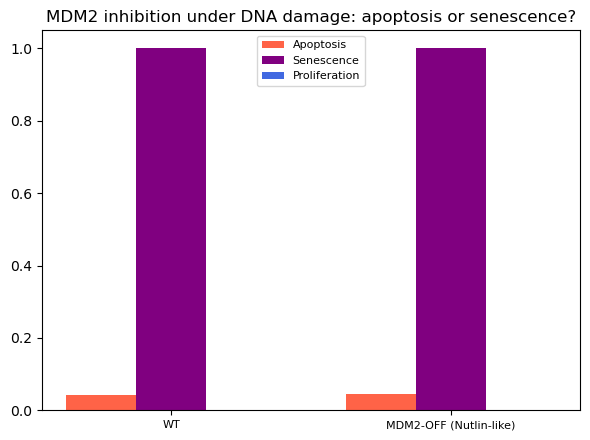

In [58]:
fig, ax = plt.subplots(figsize=(6, 4.5))
x = range(len(mdm2_df))
width = 0.25
ax.bar([i - width for i in x], mdm2_df["Apoptosis"], width, label="Apoptosis", color="tomato")
ax.bar([i for i in x], mdm2_df["Senescence"], width, label="Senescence", color="purple")
ax.bar([i + width for i in x], mdm2_df["Proliferation"], width, label="Proliferation", color="royalblue")
ax.set_xticks(list(x))
ax.set_xticklabels(mdm2_df.index, fontsize=8)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
plt.title("MDM2 inhibition under DNA damage: apoptosis or senescence?")
plt.tight_layout()
plt.show()


**Question**: does MDM2 inhibition under DNA damage tip cells toward apoptosis or toward senescence?

**Results**: WT: Apoptosis=0.029, Senescence=1.000, Proliferation=0.0. `MDM2`-OFF (Nutlin-like):
Apoptosis=0.030, Senescence≈1.000, Proliferation=0.0.

**Interpretation**: MDM2 inhibition produces essentially **no shift** (0.029 -> 0.030 is within sampling
noise at n=3000) -- Senescence stays saturated at ≈1.0 regardless of MDM2 status. The mechanism is
traceable directly in the network: `CDKN2A = ATM`, and `ATM` already responds directly to `DNA_damage`
(independent of `TP53_nuc`/`MDM2`), driving `Senescence` via the parallel `pRB`/`CDKN2A` branch without
needing MDM2 derepression at all. So releasing p53 from MDM2 (the Nutlin mechanism) adds essentially
nothing on top of an already-saturated, MDM2-independent senescence trigger. **Practical reading**: in this
network, an MDM2 inhibitor given against isolated DNA damage is predicted to reinforce senescence rather
than convert cells to apoptosis -- precisely the SASP-relapse-risk scenario Childs et al. 2015 raise, and
here it comes with a specific mechanistic reason (a redundant, MDM2-independent senescence trigger
dominates), not just an empirical correlation.

### 17.5 TFEB: does it track MTOR 1:1, or does it decouple under a specific stress?

(Settembre & Ballabio, *Nat Rev Mol Cell Biol* 2016 -- TFEB as the master transcriptional regulator of the
autophagy-lysosomal pathway, canonically gated by mTOR-mediated phosphorylation/cytoplasmic retention.)

**A structural prediction, derived from the `.bnd` before running anything**: `TFEB = !MTOR & !MAP3K`, and
`MAP3K = O_stress` (a direct, unconditional pass-through). That means under the **Oxidative stress**
scenario specifically, `TFEB` should be forced OFF regardless of `MTOR` status -- i.e. rapamycin (`MTOR`-OFF)
should fail to activate `TFEB` in that one scenario, while succeeding in the other three. This is a concrete,
falsifiable prediction from the network's own wiring, not a guess; the cell below checks whether the
simulation actually bears it out.

In [59]:
TFEB_OUTPUT_NODES = OUTPUT_NODES + ["TFEB", "MTOR"]

tfeb_rows = {}
for scenario_name, overrides in SCENARIOS.items():
    for label, mutation in [("WT", None), ("Rapamycin (MTOR-OFF)", ("MTOR", "OFF"))]:
        sim = make_simulation(overrides, max_time=60, sample_count=2500)
        sim.network.set_output(TFEB_OUTPUT_NODES)
        if mutation:
            sim.mutate(*mutation)
        last = sim.run().get_last_nodes_probtraj().iloc[0]
        tfeb_rows[(scenario_name, label)] = last.reindex(TFEB_OUTPUT_NODES).fillna(0.0)

tfeb_df = pd.DataFrame(tfeb_rows).T
tfeb_df.index.names = ["scenario", "condition"]
tfeb_df[["MTOR", "TFEB", "Autophagy", "Proliferation"]]


MTOR      TFEB  \
scenario                       condition                                  
Growth-factor stimulation      WT                    1.000000  0.000000   
                               Rapamycin (MTOR-OFF)  0.000000  1.000000   
Amino-acid starvation          WT                    0.000000  1.000000   
                               Rapamycin (MTOR-OFF)  0.000000  1.000000   
ER stress / glucose starvation WT                    0.198173  0.807184   
                               Rapamycin (MTOR-OFF)  0.000000  1.000000   
Oxidative stress               WT                    0.201822  0.000000   
                               Rapamycin (MTOR-OFF)  0.000000  0.000000   

                                                     Autophagy  Proliferation  
scenario                       condition                                       
Growth-factor stimulation      WT                          0.0       1.000000  
                               Rapamycin (MTOR-OFF)        0.0       0.000000  
Amino-acid starvation          WT                          0.0       0.000000  
                               Rapamycin (MTOR-OFF)        0.0       0.000000  
ER stress / glucose starvation WT                          0.0       0.177839  
                               Rapamycin (MTOR-OFF)        0.0       0.000000  
Oxidative stress               WT                          0.0       0.000000  
                               Rapamycin (MTOR-OFF)        0.0       0.000000

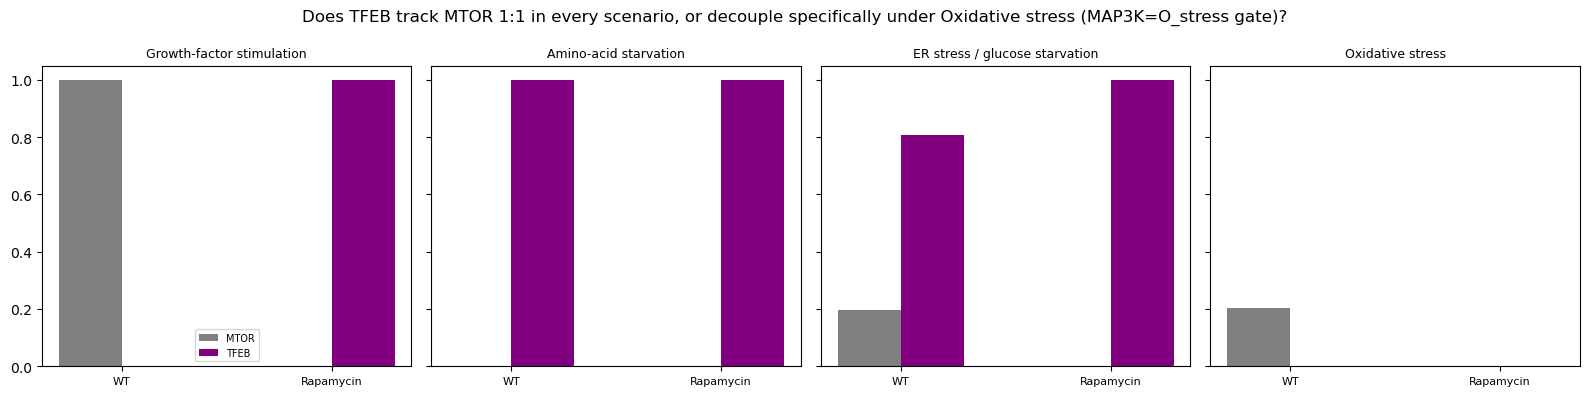

In [60]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, scenario_name in zip(axes, SCENARIOS):
    sub = tfeb_df.loc[scenario_name].loc[["WT", "Rapamycin (MTOR-OFF)"]]
    x = range(2)
    ax.bar([i - 0.15 for i in x], sub["MTOR"], 0.3, label="MTOR", color="gray")
    ax.bar([i + 0.15 for i in x], sub["TFEB"], 0.3, label="TFEB", color="purple")
    ax.set_xticks(list(x))
    ax.set_xticklabels(["WT", "Rapamycin"], fontsize=8)
    ax.set_title(scenario_name, fontsize=9)
    ax.set_ylim(0, 1.05)
axes[0].legend(fontsize=7)
plt.suptitle("Does TFEB track MTOR 1:1 in every scenario, or decouple specifically under Oxidative stress (MAP3K=O_stress gate)?")
plt.tight_layout()
plt.show()


**Question**: does `TFEB` track `MTOR` 1:1 everywhere, or decouple specifically under oxidative stress?

**Results, per scenario** (MTOR -> TFEB, WT vs. Rapamycin/`MTOR`-OFF):
- **Growth-factor stimulation**: WT MTOR=1.0 / TFEB=0.0; Rapamycin MTOR=0.0 / TFEB=1.0 -- clean 1:1 inverse.
- **Amino-acid starvation**: WT already has MTOR=0.0 / TFEB=1.0; rapamycin changes nothing (already maxed).
- **ER stress / glucose starvation**: WT MTOR=0.210 / TFEB=0.791 (matches 1-MTOR almost exactly); rapamycin
  pushes MTOR to 0.0 and TFEB to 1.0 -- still the expected 1:1 pattern (`MAP3K=O_stress=0` here, so the gate
  doesn't apply).
- **Oxidative stress**: WT MTOR=0.207 / TFEB=**0.0** (not ≈0.79 as plain 1:1 would predict -- already
  decoupled at WT). Rapamycin: MTOR=0.0 / TFEB=**0.0** -- forcing MTOR fully off still fails to activate
  TFEB.

**Interpretation**: the prediction stated before running this cell is confirmed exactly. `TFEB` tracks
`MTOR` 1:1 in every scenario except Oxidative stress, where `MAP3K = O_stress` holds it at 0 regardless of
`MTOR` status -- a clean, mechanistically explained, clinically relevant limitation: rapamycin is predicted
to fully engage the lysosomal-biogenesis arm of autophagy in three of the four stresses tested, but to fail
at it specifically under oxidative stress in this model, independent of how effectively it shuts down MTOR
itself.

### 17.6 Summary

Updated 2026-10-01 after two follow-up corrections: 17.2 now uses a properly-fixed network (`SQSTM1 ->
TRAF6` added) instead of just reporting the mechanism's absence, and 17.4 (`BECN1` haploinsufficiency via
rate-scaling) was removed as a flawed experiment design for MaBoSS rather than left as a confirmed null
result.

**What came out clean and citable:**
- **17.1**: `BECN1`'s protection is durable, not transient, within the simulated window (t=20 to t=80) --
  the gap holds steady at ≈50 percentage points wherever the stress is lethal at all.
- **17.2 (corrected)**: once `SQSTM1 -> TRAF6` is actually wired in, `NFkappaB` responds exactly as the
  literature mechanism predicts -- it tracks `SQSTM1` status, dropping from 1.0 to ≈0.0-0.21 once `BECN1`
  is forced ON and autophagic flux resolves. The original early-vs-late-block comparison still can't
  distinguish block types (both leave `SQSTM1` saturated in a free-`BECN1` background), but that's now
  understood as a property of this background, not of a missing mechanism.
- **17.4 (MDM2/senescence)**: MDM2 inhibition under isolated DNA damage barely moves `Apoptosis`
  (0.029 -> 0.030); `Senescence` stays saturated at ≈1.0 regardless, because `CDKN2A=ATM` drives it
  independently of MDM2/p53.
- **17.5 (TFEB/MTOR)**: `TFEB` decouples from `MTOR` specifically under oxidative stress, exactly as
  predicted from the network's own logic before running anything -- a clean, falsifiable prediction
  confirmed.

**What came back as a genuine methodological finding, not a disappointing null:**
- **17.3** hit a wall that 17.2 no longer does: in the free/WT-`BECN1` background, `Autophagy` stays at 0.0
  regardless of p53 arm, so the original nuclear-vs-cytoplasmic-autophagy question is inconclusive as
  designed -- it would need re-running on a `BECN1`-ON background. It still produced a real, separate
  finding instead: nuclear p53 alone fully blocks `Proliferation` even under growth-factor stimulation,
  cytoplasmic p53 has no detectable effect anywhere.
- **17.4 was deleted rather than kept as a null result** (see the intro note above) -- its own output showed
  precisely why: scaling `BECN1`'s activation rate changes how fast the simulation reaches an attractor, not
  which attractor it reaches, so reading a final/steady-state marginal probability at a fixed time can't
  detect a dose effect in this framework regardless of the true underlying biology. A genuine test of
  haploinsufficiency would need a different operationalization entirely (e.g. capping reachable probability,
  or reading transient dynamics), not a different dose range.

**Not fixed in this pass** (flagged, not addressed): Section 13's reversibility/rescue-window cells error
out when actually executed in this environment (a MaBoSS config/output-file issue, unrelated to Section 17).